### Column Consistency Check Across CSV Files

Before merging multiple CSV files into a single dataset, it is important to verify that all files share the same column structure. Differences in column names or ordering can lead to incorrect merging and introduce missing values.

The following code performs a column validation step:

1. All CSV files in the specified directory are located using the `glob` library.
2. The column names from the first CSV file are used as the reference schema.
3. For each remaining file, only the header (column names) is read using `pandas.read_csv()` with `nrows=0`, which avoids loading the full dataset into memory.
4. The column structure of each file is compared with the reference columns.
5. A message is printed indicating whether the columns match or if a mismatch is detected.

This approach ensures structural consistency across all datasets before concatenating them into a single dataframe.

In [1]:
import pandas as pd
import glob

files = glob.glob(r"C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-510\Project\Dataset_finalised\*.csv") # Locates all the csv files in the specified directory

base_columns = pd.read_csv(files[0], nrows=0).columns

for file in files[1:]:
    current_columns = pd.read_csv(file, nrows=0).columns
    
    if not base_columns.equals(current_columns):
        print(f"Column mismatch found in {file}")
    else:
        print(f"{file} columns match")

C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-510\Project\Dataset_finalised\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv columns match
C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-510\Project\Dataset_finalised\Friday-WorkingHours-Morning.pcap_ISCX.csv columns match
C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-510\Project\Dataset_finalised\Monday-WorkingHours.pcap_ISCX.csv columns match
C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-510\Project\Dataset_finalised\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv columns match
C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-510\Project\Dataset_finalised\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv columns match
C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-510\Project\Dataset_finalised\Tuesday-WorkingHours.pcap_ISCX.csv columns match
C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-510\Project\Dataset_finalised\Wednesday-workingHours.pcap_ISCX.csv columns match


### Detecting Negative Values in Numeric Features

This code iterates through all CSV files in the dataset directory and checks for the presence of negative values in numeric columns.

First, each CSV file is loaded into a temporary pandas DataFrame. To ensure accurate datatype inference, the `low_memory=False` parameter is used when reading the file.

Next, only numeric columns are selected using the `select_dtypes()` function. This step is important because negative values are meaningful only for numeric data and not for categorical or textual features.

The code then evaluates whether any values in these numeric columns are less than zero. A boolean comparison (`numeric_df < 0`) is performed, and the resulting True values are summed column-wise to count how many negative values appear in each column.

Columns that contain at least one negative value are filtered and stored. If such columns exist in the file, the script prints the file name along with the column names and the number of negative entries detected.

This process helps identify potential data quality issues, anomalies, or unexpected values within the dataset before further preprocessing or model training.

In [2]:
for file in files:  
    # Iterate through each CSV file path stored in the list "files"

    df_temp = pd.read_csv(file, low_memory=False)
    df_temp.columns = df_temp.columns.str.strip()  # Removes leading and trailing spaces from column names
    # Read the current CSV file into a temporary pandas DataFrame
    # low_memory=False ensures pandas reads the file in one pass for correct datatype inference

    numeric_df = df_temp.select_dtypes(include='number')  
    # Select only the columns that contain numeric values (integers or floats)
    # This avoids checking negative values in non-numeric columns like text or IP addresses

    negative_counts = (numeric_df < 0).sum()  
    # Create a boolean dataframe where values < 0 are True
    # Then sum the True values column-wise to count how many negative values each column contains

    negative_columns = negative_counts[negative_counts > 0]  
    # Filter the results to keep only columns where the count of negative values is greater than zero

    if not negative_columns.empty:  
        # Check whether any columns with negative values were found

        print(f"\nNegative values in file: {file}")  
        # Print the name/path of the file where negative values were detected

        print(negative_columns)  
        # Display the column names along with the number of negative values detected


Negative values in file: C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-510\Project\Dataset_finalised\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Flow Duration                  2
Flow Bytes/s                   2
Flow Packets/s                 2
Flow IAT Mean                  2
Flow IAT Max                   2
Flow IAT Min                 108
Fwd IAT Min                    6
Init_Win_bytes_forward     32925
Init_Win_bytes_backward    88299
dtype: int64

Negative values in file: C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-510\Project\Dataset_finalised\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Flow Duration                 36
Flow Bytes/s                  36
Flow Packets/s                36
Flow IAT Mean                 36
Flow IAT Max                  36
Flow IAT Min                 176
Init_Win_bytes_forward     60210
Init_Win_bytes_backward    76942
dtype: int64

Negative values in file: C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-510\Project\Dataset_finalised\Frida

### Merging Multiple CSV Files into a Single DataFrame and Cleaning Dataset Columns

This code combines multiple CSV files into a single DataFrame and performs essential column cleaning to ensure consistency and remove redundancy.

First, all CSV files are read and concatenated using `pd.concat()`. The `ignore_index=True` parameter ensures that the row indices are reset, creating a continuous index across the merged dataset.

Next, column names are cleaned by removing any leading or trailing whitespace using `str.strip()`. This prevents issues caused by inconsistent formatting in column headers.

Since the dataset may contain duplicate columns, Pandas automatically appends suffixes such as `.1`, `.2`, etc., to make column names unique during loading. These suffixes are removed using a regular expression so that logically identical columns can be identified.

Finally, duplicate columns are removed by retaining only the first occurrence of each column name using `df.loc[:, ~df.columns.duplicated()]`. This step ensures that redundant features are eliminated, resulting in a cleaner and more reliable dataset.

The `df.info()` function is then used to display a concise summary of the DataFrame, including column names, data types, and non-null counts, while `df.head()` provides a preview of the first few rows for inspection.

In [3]:
df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True) # Reads each csv file and concatenates them into a single dataframe, ignoring the original index
df.columns = df.columns.str.strip()  # Removes leading and trailing spaces from column names
df.columns = df.columns.str.replace(r'\.\d+$', '', regex=True) # Removes suffixes like '.1', '.2', etc. from column names (added by pandas for duplicate columns),
# so that logically identical columns can be recognized and handled properly
df = df.loc[:, ~df.columns.duplicated()] # Removes duplicate columns by keeping only the first occurence of each column name

In [4]:
df.info() # Displays a concise summary of the DataFrame
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 78 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


**Pre-check for clean up** <br>
Grouping the dataset by the Label column to calculate the number of missing values for each feature within each class. Then filtering out columns with no missing values to focus only on relevant features. This helps understand how missing data is distributed across different categories (e.g., benign vs attack).

In [5]:
missing_by_label = df.groupby("Label").apply(lambda x: x.isna().sum())

# Filter only columns with missing values
missing_by_label = missing_by_label.loc[:, missing_by_label.sum() > 0]

print(missing_by_label)

missing = df.isna().sum()

C:\Users\kalyan_developer\AppData\Local\Temp\ipykernel_21812\4248142842.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_label = df.groupby("Label").apply(lambda x: x.isna().sum())


                            Flow Bytes/s
Label                                   
BENIGN                               409
Bot                                    0
DDoS                                   0
DoS GoldenEye                          0
DoS Hulk                             949
DoS Slowhttptest                       0
DoS slowloris                          0
FTP-Patator                            0
Heartbleed                             0
Infiltration                           0
PortScan                               0
SSH-Patator                            0
Web Attack � Brute Force               0
Web Attack � Sql Injection             0
Web Attack � XSS                       0


### Handling Negative Values in TCP Window Size Features

During exploratory data analysis, the features **`Init_Win_bytes_forward`** and **`Init_Win_bytes_backward`** were found to contain a large number of negative values. These variables represent the initial TCP window size advertised by the client and the server during the establishment of a TCP connection. Since TCP window sizes represent the number of bytes that can be received before an acknowledgment is required, these values cannot be negative in practice.

In the CICIDS dataset, negative values (commonly `-1`) typically indicate that the TCP window size information was **missing, unavailable, or not applicable** for a particular flow. This situation can occur when only one direction of the flow was captured, when the flow was not based on the TCP protocol, or when the feature extraction process could not determine the window size.

Because these two columns contained **a very large number of negative values**, removing all rows with such entries would have resulted in the loss of a substantial portion of the dataset and could potentially bias the analysis or reduce the effectiveness of the machine learning model. Therefore, instead of dropping those rows, negative values were replaced with **0** using the `clip(lower=0)` function. This transformation ensures that invalid negative values are corrected while preserving the dataset size and maintaining logical consistency in the features.


In [6]:
df['Init_Win_bytes_forward'] = df['Init_Win_bytes_forward'].clip(lower=0)
df['Init_Win_bytes_backward'] = df['Init_Win_bytes_backward'].clip(lower=0)

### Removing Rows with Negative Values and Analyzing Label Distribution

This code performs data cleaning by removing rows that contain negative values in any numeric column and then analyzes the distribution of labels in the dataset.

First, the total number of rows in the dataset is stored in the variable `before`. A filtering condition is then applied to retain only those rows where all numeric features are greater than or equal to zero. This is achieved by selecting numeric columns, checking for non-negative values, and ensuring that the condition holds true across each row.

After filtering, the updated number of rows is stored in the variable `after`. The difference between `before` and `after` gives the total number of rows removed due to invalid negative values, which is printed for reference.

Finally, the distribution of the target variable (`Label`) is examined using `value_counts()`. This provides the frequency of each class in the cleaned dataset, helping to understand class balance and the impact of data cleaning on different categories.

In [7]:
before = len(df)
df = df[(df.select_dtypes(include='number') >= 0).all(axis=1)]
after = len(df)
print(f"Rows removed: {before - after}")
df['Label'].value_counts()

Rows removed: 4283


Label
BENIGN                        2269957
DoS Hulk                       229965
PortScan                       158930
DDoS                           128008
DoS GoldenEye                   10288
FTP-Patator                      7934
SSH-Patator                      5895
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       35
Web Attack � Sql Injection         21
Heartbleed                          7
Name: count, dtype: int64

### Detection and Removal of Infinite Values

The dataset was examined for the presence of infinite values, which can arise due to division-based feature calculations such as rates (e.g., bytes per second or packets per second). These values typically occur when the denominator in a calculation is zero, leading to undefined or extremely large results.

Since infinite values can negatively impact machine learning algorithms and lead to training failures, a preprocessing step is performed to identify and remove them.

First, only numerical columns were selected, as infinite values are applicable only to numeric data types. A boolean mask was then created to detect rows containing infinite values across any numerical feature. Additionally, the number of infinite values present in each column was calculated to identify problematic features.

Finally, all rows containing infinite values were removed from the dataset, ensuring that the data used for model training consists only of valid and finite numerical values. This step improves the stability and reliability of subsequent modeling processes.

In [8]:
import numpy as np
numeric_df = df.select_dtypes(include=[np.number])
inf_mask = np.isinf(numeric_df).any(axis=1) # Creating a boolean mask where True indicates row contains infinite values
inf_count = np.isinf(numeric_df).sum()

# Show only columns where inf exists
inf_count = inf_count[inf_count > 0]

print("\nCount of infinite values per column:")
print(inf_count)

# Remove rows with infinite values
df = df[~inf_mask]


Count of infinite values per column:
Flow Bytes/s      1509
Flow Packets/s    1509
dtype: int64



### Missing and Infinite Value Analysis post data cleaning

The dataset was analyzed to detect missing and infinite values that could affect model performance.

Missing values were computed by grouping the data based on the target variable (`Label`) to understand their distribution across traffic types. Only columns containing missing values were displayed for focused analysis.

For infinite values, only numerical features were considered. The count of infinite values per column was calculated and displayed for columns where such values were present.

If no missing or infinite values were found, appropriate messages were printed. This step ensures data quality before proceeding with preprocessing and model training.

In [9]:
missing_by_label = df.groupby("Label").apply(lambda x: x.isna().sum())

# Filter only columns with missing values
missing_by_label = missing_by_label.loc[:, missing_by_label.sum() > 0]

if missing_by_label.empty:
    print("No missing values found in any column after filtering.")
else:
    print(missing_by_label)

# Filter rows containing infinite values

numeric_df = df.select_dtypes(include=[np.number])
inf_count = np.isinf(numeric_df).sum()

# Show only columns where inf exists
inf_count = inf_count[inf_count > 0]

if inf_count.empty:
    print("No infinite values found in any column after filtering.")
else:
    print("\nCount of infinite values per column:")
    print(inf_count)


C:\Users\kalyan_developer\AppData\Local\Temp\ipykernel_21812\2196788420.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_label = df.groupby("Label").apply(lambda x: x.isna().sum())


No missing values found in any column after filtering.
No infinite values found in any column after filtering.


## Distribution of Network Traffic Labels

The below visualization represents the distribution of different network traffic categories in the dataset using a horizontal count plot.

### Key Observations:

- The dataset is **highly imbalanced**, with **BENIGN traffic dominating** the dataset by a very large margin.
- Among attack types, **DoS Hulk**, **PortScan**, and **DDoS** have relatively higher occurrences compared to others.
- Several attack categories such as:
  - Heartbleed  
  - SQL Injection  
  - Infiltration  
  - Web Attacks (XSS, Brute Force)  
  have **extremely low sample counts**.

### Interpretation:

- The imbalance indicates that a model trained directly on this dataset may become **biased toward predicting the majority class (BENIGN)**.
- Rare attack types may be **poorly learned or completely ignored** by the model.

### Implications for Modeling:

- This imbalance motivates the need for:
  - Reformulating the problem as **binary classification (BENIGN vs ATTACK)**

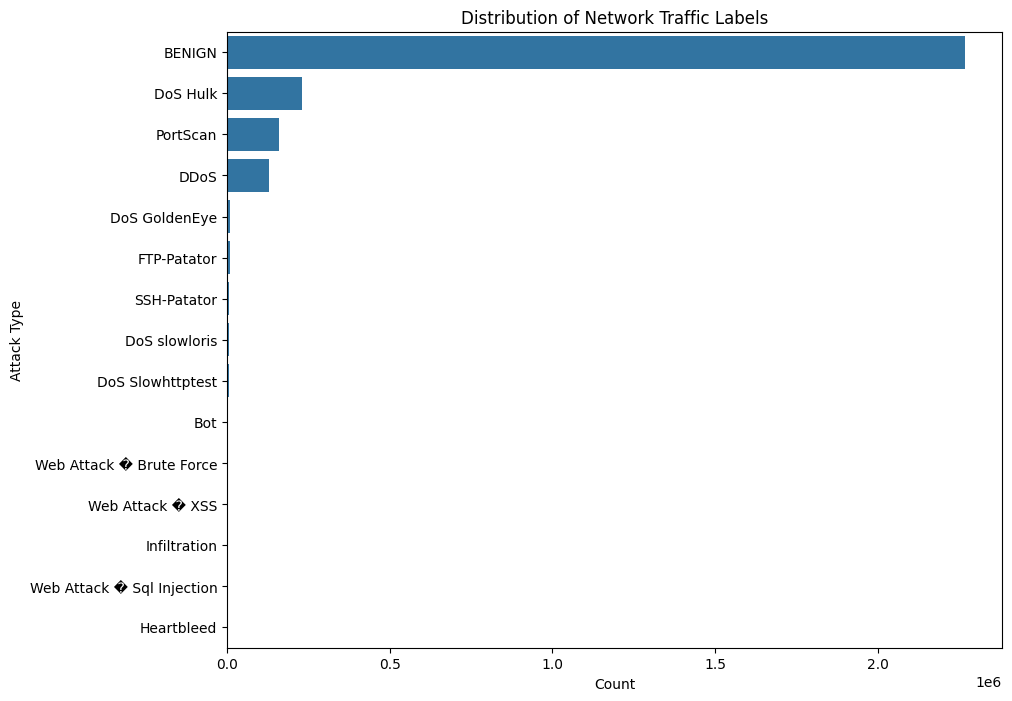

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
order = df["Label"].value_counts().index # Retrieving the unique labels sorted by their frequency

plt.figure(figsize=(10,8))
sns.countplot(data=df, y="Label", order=order)

plt.title("Distribution of Network Traffic Labels")
plt.xlabel("Count")
plt.ylabel("Attack Type")

plt.show()

## Feature Selection using Correlation Analysis

In this step, feature selection was performed to reduce redundancy and improve model efficiency.

### Approach:

1. **Correlation Matrix Computation**
   - Only numerical features were selected from the dataset.
   - A correlation matrix was computed to measure the relationship between each pair of features.

2. **Removing Duplicate Relationships**
   - Only the **upper triangle** of the correlation matrix was considered to avoid duplicate feature pairs.

3. **Identifying Highly Correlated Features**
   - A threshold of **0.95** was used.
   - Feature pairs with correlation greater than this threshold were considered highly correlated.
   - A total of **57 highly correlated pairs** were identified.

4. **Feature Reduction**
   - From each highly correlated pair, one feature was removed to eliminate redundancy.
   - This resulted in:
     - **25 features removed**
     - **52 features retained**

5. **Final Dataset Creation**
   - A reduced dataset (`df_selected`) was created using the selected features along with the target variable (`Label`).

### Results:

- **Original dataset shape:** (2,826,460, 78)
- **Reduced dataset shape:** (2,826,460, 53)

### Interpretation:

- Many features in the dataset were found to be **highly correlated or derived from each other**, indicating redundancy.
- Removing such features helps:
  - Reduce dimensionality  
  - Improve model training speed  
  - Minimize overfitting  
  - Enhance interpretability  

### Result:

Correlation-based feature selection effectively reduced the feature space while preserving the most informative attributes, preparing the dataset for efficient machine learning modeling.

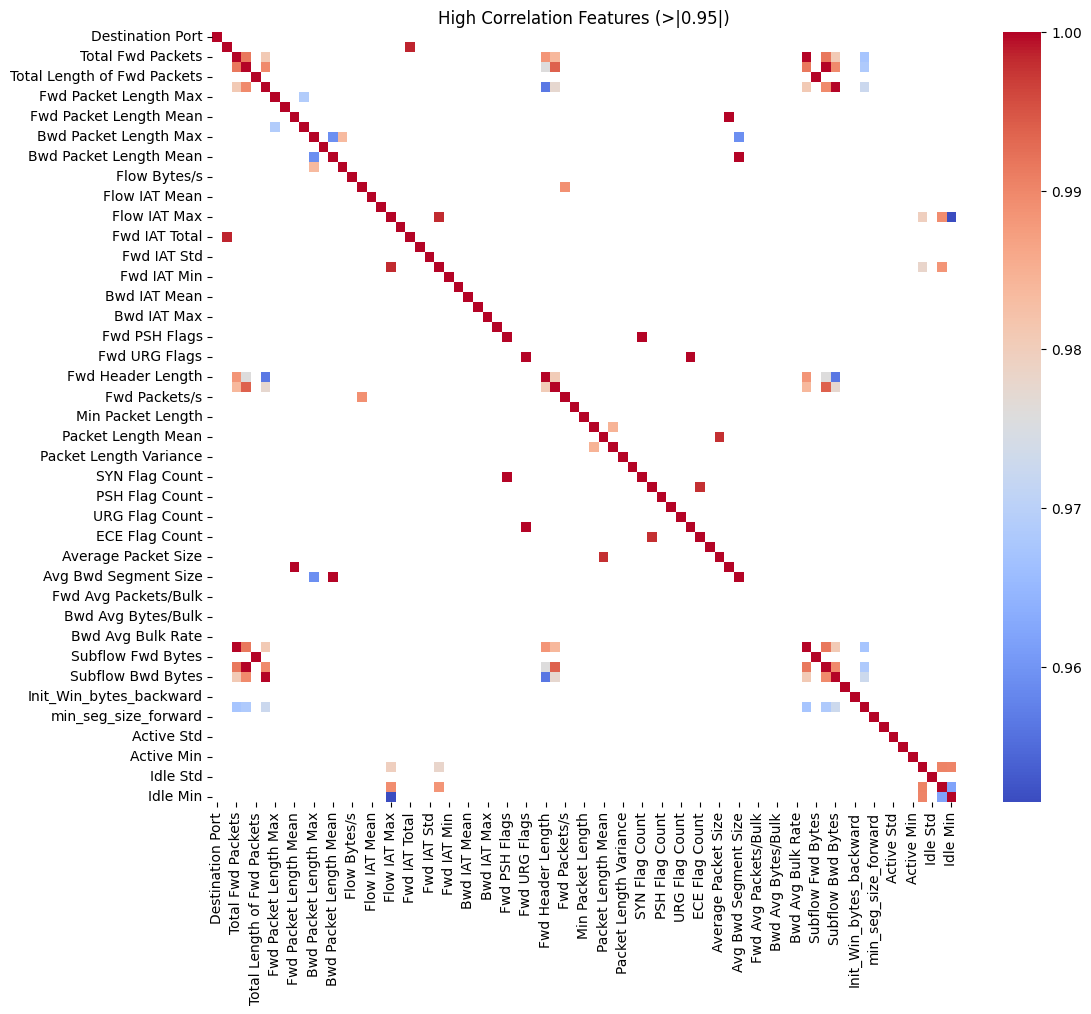

In [11]:
import numpy as np

numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

# Keep only strong correlations
threshold = 0.95
corr_filtered = corr[(np.abs(corr) > threshold)]

plt.figure(figsize=(12,10))
sns.heatmap(corr_filtered, cmap='coolwarm', annot=False)
plt.title("High Correlation Features (>|0.95|)")
plt.show()

In [12]:
# Step 1: Compute correlation
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

# Step 2: Take upper triangle only (avoid duplicates)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Step 3: Find highly correlated pairs
threshold = 0.95

high_corr_pairs = [
    (col1, col2, upper.loc[col1, col2])
    for col1 in upper.columns
    for col2 in upper.columns
    if abs(upper.loc[col1, col2]) > threshold
]

# Step 4: Print results
for col1, col2, corr_value in high_corr_pairs:
    print(f"{col1}  ↔  {col2}  →  {corr_value:.2f}")

# Step 5: Find columns to DROP

to_drop = [
    col for col in upper.columns
    if any(abs(upper[col]) > threshold)
]

# Step 6: Columns to KEEP
selected_columns = [col for col in numeric_df.columns if col not in to_drop]

print(f"\nTotal highly correlated pairs (>|{threshold}|): {len(high_corr_pairs)}")
print(f"Columns to drop: {len(to_drop)}")
print(f"Columns to keep: {len(selected_columns)}")
print("\nSelected columns are given below :")
for col in selected_columns:
    print(col)

# Step 7 : Feature selection using correlation threshold
df_selected = df[selected_columns + ["Label"]]
print(f"\nOriginal dataset shape: {df.shape}")
print(f"Selected dataset shape: {df_selected.shape}")

Flow Duration  ↔  Fwd IAT Total  →  1.00
Total Fwd Packets  ↔  Total Backward Packets  →  0.99
Total Fwd Packets  ↔  Total Length of Bwd Packets  →  0.98
Total Fwd Packets  ↔  Fwd Header Length  →  0.99
Total Fwd Packets  ↔  Bwd Header Length  →  0.98
Total Fwd Packets  ↔  Subflow Fwd Packets  →  1.00
Total Fwd Packets  ↔  Subflow Bwd Packets  →  0.99
Total Fwd Packets  ↔  Subflow Bwd Bytes  →  0.98
Total Fwd Packets  ↔  act_data_pkt_fwd  →  0.97
Total Backward Packets  ↔  Total Length of Bwd Packets  →  0.99
Total Backward Packets  ↔  Fwd Header Length  →  0.98
Total Backward Packets  ↔  Bwd Header Length  →  0.99
Total Backward Packets  ↔  Subflow Fwd Packets  →  0.99
Total Backward Packets  ↔  Subflow Bwd Packets  →  1.00
Total Backward Packets  ↔  Subflow Bwd Bytes  →  0.99
Total Backward Packets  ↔  act_data_pkt_fwd  →  0.97
Total Length of Fwd Packets  ↔  Subflow Fwd Bytes  →  1.00
Total Length of Bwd Packets  ↔  Fwd Header Length  →  0.96
Total Length of Bwd Packets  ↔  Bwd Head

### Binary Label Encoding for Intrusion Detection

The original dataset contains multiple traffic categories, including one normal class (`BENIGN`) and several attack classes (e.g., DoS, DDoS, PortScan, etc.). Since the objective of this project is to build a Network Intrusion Detection System (IDS) that distinguishes between normal and malicious traffic, the multi-class labels are transformed into a binary classification problem.

In this transformation:
- `BENIGN` traffic is encoded as **0** (normal behavior)
- All other categories are grouped and encoded as **1** (attack traffic)

To ensure robustness, the label values are cleaned using string operations (`strip` and `upper`) to handle inconsistencies such as extra spaces or variations in letter casing.

This binary encoding simplifies the modeling process, aligns with real-world IDS use cases (attack vs normal detection), and enables the application of both supervised and unsupervised machine learning algorithms effectively.

In [13]:
import numpy as np

df["Traffic_Label"] = np.where(
    df["Label"].str.strip().str.upper() == "BENIGN",
    0,
    1
)
print("0 = Benign, 1 = Attack")
print(df["Traffic_Label"].value_counts())

0 = Benign, 1 = Attack
Traffic_Label
0    2268589
1     556362
Name: count, dtype: int64


# Attack Category Consolidation and Encoding

## Objective

The original CICIDS2017 dataset contains multiple attack labels representing different intrusion types such as DoS attacks, reconnaissance activities, credential attacks, web-based attacks, and malware-related events.

Many of these attack classes contain a relatively small number of samples, resulting in severe class imbalance. To simplify the classification problem and create more meaningful attack groupings, the original attack labels were consolidated into a smaller set of high-level attack categories.

This process serves two primary purposes:

1. Reduce class fragmentation and improve class representation.
2. Enable the development of a multiclass intrusion detection model capable of identifying broader attack families rather than individual attack variants.

---

# Attack Category Mapping

The original CICIDS2017 attack labels were mapped into six high-level categories:

| Original Label | Attack Category |
|---------------|----------------|
| BENIGN | Benign |
| DoS Hulk | DoS_DDoS |
| DoS GoldenEye | DoS_DDoS |
| DoS slowloris | DoS_DDoS |
| DoS Slowhttptest | DoS_DDoS |
| DDoS | DoS_DDoS |
| PortScan | Reconnaissance |
| FTP-Patator | Credential_Attack |
| SSH-Patator | Credential_Attack |
| Web Attack – Brute Force | Credential_Attack |
| Web Attack – XSS | Web_Attack |
| Web Attack – SQL Injection | Web_Attack |
| Bot | Malware_Compromise |
| Infiltration | Malware_Compromise |
| Heartbleed | Malware_Compromise |

The mapping was implemented using a Python dictionary and applied to the original `Label` column.

```python
df['Attack_Category'] = df['Label'].map(attack_mapping)
```

---

# Label Encoding

Machine learning algorithms require numerical target values rather than text labels.

Therefore, the newly created attack categories were transformed into integer-encoded values using Scikit-learn's `LabelEncoder`.

```python
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['Attack_Class'] = label_encoder.fit_transform(
    df['Attack_Category']
)
```

The resulting encoding was:

| Attack Category | Encoded Class |
|----------------|--------------|
| Benign | 0 |
| Credential_Attack | 1 |
| DoS_DDoS | 2 |
| Malware_Compromise | 3 |
| Reconnaissance | 4 |
| Web_Attack | 5 |

These encoded values were later used as target labels for multiclass classification experiments.

---

# Distribution of Attack Categories

After category consolidation, the dataset distribution became:

| Attack Category | Count |
|----------------|---------:|
| Benign | 2,268,589 |
| DoS_DDoS | 379,554 |
| Reconnaissance | 158,804 |
| Credential_Attack | 15,333 |
| Malware_Compromise | 1,998 |
| Web_Attack | 673 |

Total records:

```text
2,825,951
```

---

# Percentage Distribution

The percentage representation of each category within the dataset is shown below.

| Attack Category | Percentage |
|----------------|-----------:|
| Benign | 80.31% |
| DoS_DDoS | 13.44% |
| Reconnaissance | 5.62% |
| Credential_Attack | 0.54% |
| Malware_Compromise | 0.07% |
| Web_Attack | 0.02% |

---

# Analysis of Class Distribution

The category distribution reveals a significant class imbalance within the CICIDS2017 dataset.

### Benign Traffic

Benign traffic constitutes approximately:

```text
80.31%
```

of the entire dataset, making it the dominant class.

---

### DoS and DDoS Attacks

The DoS_DDoS category represents:

```text
13.44%
```

of the dataset and is the largest attack category.

This indicates that denial-of-service attacks are heavily represented in CICIDS2017 and are expected to have a strong influence on model learning.

---

### Reconnaissance Attacks

Reconnaissance traffic accounts for:

```text
5.62%
```

of the dataset.

This category primarily consists of network scanning activities such as PortScan attacks.

---

### Minority Attack Classes

The remaining categories are highly underrepresented:

| Category | Percentage |
|-----------|-----------:|
| Credential_Attack | 0.54% |
| Malware_Compromise | 0.07% |
| Web_Attack | 0.02% |

These classes contain relatively few samples and therefore present a greater classification challenge.

Models trained on the full dataset may become biased toward the majority classes unless balancing techniques are applied.

---

# Visualization Interpretation

To better understand the attack distribution, benign traffic was removed from the visualization and only attack categories were plotted.

The resulting graph shows:

- DoS_DDoS attacks dominate the attack dataset.
- Reconnaissance attacks form the second-largest category.
- Credential_Attack, Malware_Compromise, and Web_Attack categories are significantly smaller.
- The attack dataset remains highly imbalanced even after category consolidation.

This observation justifies the use of undersampling and balancing strategies in subsequent supervised learning experiments.

---

# Key Findings

- Original CICIDS2017 attack labels were consolidated into six broader attack categories.
- Label encoding converted categorical attack classes into numerical values suitable for machine learning.
- Benign traffic accounts for more than 80% of all network flows.
- DoS_DDoS and Reconnaissance represent the majority of attack traffic.
- Credential_Attack, Malware_Compromise, and Web_Attack remain severely underrepresented.
- The resulting multiclass attack taxonomy provides a more manageable and interpretable classification problem while preserving the major attack families present in the dataset.

This attack categorization framework is subsequently used to train multiclass classification models and generate attack-type probabilities that are incorporated as meta-features within the final hybrid intrusion detection system.

In [14]:
attack_mapping = {

    # Normal Traffic
    'BENIGN': 'Benign',

    # DoS / DDoS
    'DoS Hulk': 'DoS_DDoS',
    'DoS GoldenEye': 'DoS_DDoS',
    'DoS slowloris': 'DoS_DDoS',
    'DoS Slowhttptest': 'DoS_DDoS',
    'DDoS': 'DoS_DDoS',

    # Reconnaissance
    'PortScan': 'Reconnaissance',

    # Credential Attacks
    'FTP-Patator': 'Credential_Attack',
    'SSH-Patator': 'Credential_Attack',
    'Web Attack � Brute Force': 'Credential_Attack',

    # Web Attacks
    'Web Attack � XSS': 'Web_Attack',
    'Web Attack � Sql Injection': 'Web_Attack',

    # Malware / Compromise
    'Bot': 'Malware_Compromise',
    'Infiltration': 'Malware_Compromise',
    'Heartbleed': 'Malware_Compromise'
}

df['Attack_Category'] = df['Label'].map(attack_mapping)

### Encode Categories

In [15]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['Attack_Class'] = label_encoder.fit_transform(
    df['Attack_Category']
)

print(label_encoder.classes_)

['Benign' 'Credential_Attack' 'DoS_DDoS' 'Malware_Compromise'
 'Reconnaissance' 'Web_Attack']


In [16]:
# Count of each category
print(df['Attack_Category'].value_counts())

unmapped = df[df['Attack_Category'].isna()]['Label'].unique()

print("Unmapped labels:")
print(unmapped)

Attack_Category
Benign                2268589
DoS_DDoS               379554
Reconnaissance         158804
Credential_Attack       15333
Malware_Compromise       1998
Web_Attack                673
Name: count, dtype: int64
Unmapped labels:
[]


In [17]:
print(
    df['Attack_Category']
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

Attack_Category
Benign                80.31
DoS_DDoS              13.44
Reconnaissance         5.62
Credential_Attack      0.54
Malware_Compromise     0.07
Web_Attack             0.02
Name: proportion, dtype: float64


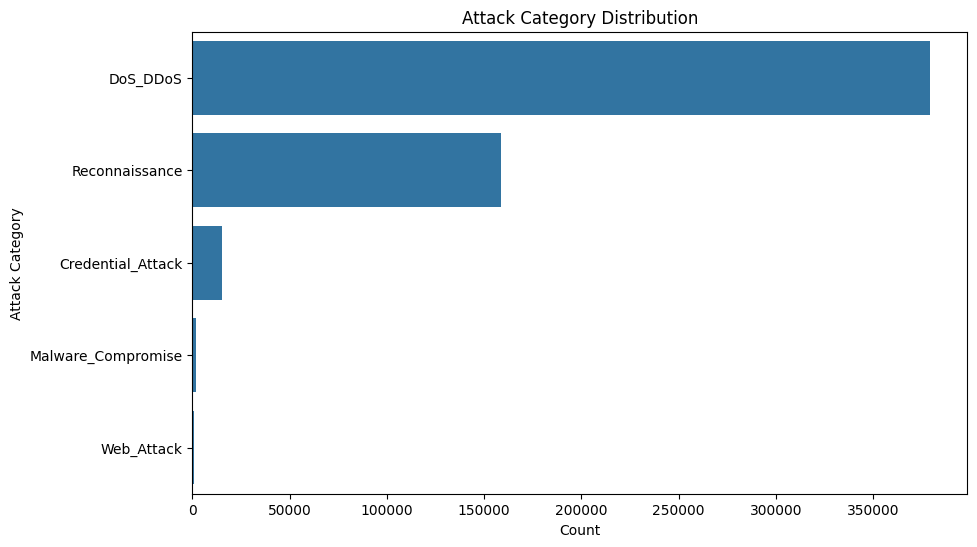

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Remove benign traffic
attack_df = df[df["Attack_Category"] != "Benign"]

plt.figure(figsize=(10,6))

sns.countplot(
    y="Attack_Category",
    data=attack_df,
    order=attack_df["Attack_Category"].value_counts().index
)

plt.title("Attack Category Distribution")
plt.xlabel("Count")
plt.ylabel("Attack Category")

plt.show()

#### before vs after consolidation

In [19]:
print("Original Labels")
print(df['Label'].value_counts())

print("\nConsolidated Categories")
print(df['Attack_Category'].value_counts())

Original Labels
Label
BENIGN                        2268589
DoS Hulk                       229965
PortScan                       158804
DDoS                           128006
DoS GoldenEye                   10288
FTP-Patator                      7931
SSH-Patator                      5895
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       35
Web Attack � Sql Injection         21
Heartbleed                          7
Name: count, dtype: int64

Consolidated Categories
Attack_Category
Benign                2268589
DoS_DDoS               379554
Reconnaissance         158804
Credential_Attack       15333
Malware_Compromise       1998
Web_Attack                673
Name: count, dtype: int64


This comparison is useful because it demonstrates how consolidating attack types reduces class imbalance and creates a more balanced multiclass dataset for training.

### Train-Test Split and Handling Class Imbalance

The dataset used in this project exhibits a significant class imbalance, where benign (normal) traffic instances greatly outnumber attack (malicious) instances. Such imbalance can bias machine learning models toward the majority class, leading to poor detection performance for minority (attack) classes, which is critical in an intrusion detection system.

To address this issue, the dataset is first divided into training and testing sets using stratified sampling. Stratification ensures that both sets preserve the original class distribution, allowing the test set to reflect real-world network traffic conditions and provide an unbiased evaluation of model performance.

After splitting, only the training data is used for balancing. This is important to avoid data leakage and ensure that the model is evaluated on realistic, imbalanced data. The training data is then balanced using undersampling, where the majority class (benign traffic) is randomly reduced to match the number of samples in the minority class (attack traffic).

The balanced training dataset enables the model to learn patterns from both classes equally, improving its ability to detect malicious traffic without being biased toward normal traffic. The dataset is then shuffled to remove any ordering bias before being used for model training.

This approach ensures a fair learning process while maintaining a realistic evaluation setup for intrusion detection performance.

In [20]:

## Train test split is being done here
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Label", "Traffic_Label", "Attack_Category", "Attack_Class"])
y = df["Traffic_Label"]
y_attack_class = df["Attack_Class"]

'''
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
'''

X_train, X_test, y_train, y_test, y_attack_train, y_attack_test = train_test_split(
    X,
    y,
    y_attack_class,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Combining train data for sampling
train_df = X_train.copy()
train_df["Traffic_Label"] = y_train

# Undersampling the majority class benign to balance the dataset

df_benign = train_df[train_df["Traffic_Label"] == 0]
df_attack = train_df[train_df["Traffic_Label"] == 1]

#df_sampled = df_benign.sample(n=len(df_attack), random_state=42)
df_benign_sampled = df_benign.sample(n=5000, random_state=42)
df_attack_sampled = df_attack.sample(n=5000, random_state=42)


train_balanced = pd.concat([df_benign_sampled, df_attack_sampled]).sample(frac=1, random_state=42)  # Shuffle the balanced dataset

train_balanced_multi = train_balanced.copy() # Create a copy of the balanced dataset for multi-class classification

print(train_balanced["Traffic_Label"].value_counts())

Traffic_Label
1    5000
0    5000
Name: count, dtype: int64


## Random Forest Model for Intrusion Detection

### Methodology

In this step, a **Random Forest classifier** was implemented to detect network intrusions using the CICIDS2017 dataset. The approach focuses on improving model performance through **hyperparameter tuning, feature selection, and robust evaluation**.

---

### 1. Data Preparation

The dataset was first divided into features and target variable:

- **Features (X):** All input variables excluding the target column (`Traffic_Label`)
- **Target (y):** Binary classification label indicating benign or attack traffic

A **balanced training dataset** (`train_balanced`) was used to address class imbalance and ensure fair learning across both classes.

---

### 2. Model Selection

A **Random Forest Classifier** was chosen due to its:

- Ability to handle high-dimensional data  
- Robustness to noise and overfitting  
- Built-in feature importance estimation  

The model was initialized with:
- `random_state=42` for reproducibility  
- `n_jobs=-1` to utilize all CPU cores for faster computation  

---

### 3. Hyperparameter Tuning

To optimize model performance, **Grid Search with Cross-Validation** was used.

#### Hyperparameters tuned:
- `n_estimators`: Number of trees in the forest  
- `max_depth`: Maximum depth of each tree  
- `min_samples_split`: Minimum samples required to split a node  
- `min_samples_leaf`: Minimum samples required at a leaf node  

A **Stratified K-Fold (5-fold)** cross-validation strategy was used to:
- Maintain class distribution across folds  
- Ensure robust and unbiased evaluation  

The best parameters obtained were:

```text
max_depth = 20  
min_samples_leaf = 2  
min_samples_split = 5  
n_estimators = 100

### 
#### Feature Importance and Selection:

Random Forest provides **feature importance scores**, which were used to identify the most influential features.

- Features were ranked based on importance  
- The **top 15 features** were selected  

This step helps:
- Reduce dimensionality  
- Improve computational efficiency  
- Enhance model interpretability  

---

### 5. Model Retraining

The model was retrained using only the **selected top features**:

- Training set → `X_train_top`  
- Test set → `X_test_top`  

This ensures the model focuses on the most relevant information.

---

### 6. Model Evaluation

The model was evaluated using:

- **Precision**
- **Recall**
- **F1-score**
- **Accuracy**

#### Results:

- Overall accuracy: **~99%**
- High precision and recall for both classes  
- Balanced performance across benign and attack traffic  

---

### Interpretation of Results

- The model demonstrates **strong classification capability**, effectively distinguishing between benign and malicious traffic.  
- The small gap between precision and recall indicates **balanced error handling**.  
- The use of feature selection reduces redundancy while maintaining high performance.  

---

### Conclusion

The Random Forest model, combined with hyperparameter tuning and feature selection, achieves **high accuracy and robustness** for intrusion detection. 

However, given the high performance, further validation using more challenging data splits (e.g., time-based or attack-based splits) is recommended to ensure **generalization to real-world scenarios**.

## Classification Report Analysis

The performance of the Random Forest model was evaluated using standard classification metrics, including **precision, recall, F1-score, and accuracy**. The results are summarized below:

---

### Overall Performance

- **Accuracy:** 99%
- **Macro Average F1-score:** 0.99
- **Weighted Average F1-score:** 0.99

These results indicate that the model achieves **very high overall performance** and maintains a strong balance between precision and recall.

---

### Class-wise Performance

#### Class 0 (Benign Traffic)
- **Precision:** 1.00  
- **Recall:** 0.99  
- **F1-score:** 1.00  

The model is highly effective in identifying benign traffic:
- Very few benign samples are misclassified as attacks  
- High precision indicates minimal false positives  

---

#### Class 1 (Attack Traffic)
- **Precision:** 0.98  
- **Recall:** 1.00  
- **F1-score:** 0.99  

The model performs extremely well in detecting attack traffic:
- Nearly all attack instances are correctly identified (high recall)  
- Slightly lower precision indicates a small number of false positives  

---

### Interpretation

- The **high recall (1.00) for attack traffic** is particularly important in intrusion detection systems, as it ensures that almost no malicious activity is missed.  
- The slightly lower precision for attack traffic suggests that some benign traffic is incorrectly flagged as malicious, which is acceptable in security contexts where **false negatives are more critical than false positives**.  
- The close alignment between macro and weighted averages indicates that the model performs consistently across both classes despite class imbalance.

---

### Conclusion

The classification results demonstrate that the model is **highly effective and reliable** for intrusion detection tasks. It achieves an excellent balance between detecting attacks and minimizing misclassification, making it suitable for practical deployment with further validation.

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Prepare training data

X_train_bal = train_balanced.drop(columns=["Traffic_Label"])
y_train_bal = train_balanced["Traffic_Label"]

# Step 2: Define Random Forest

rf = RandomForestClassifier(random_state=42, n_jobs=-1) # Use all CPU cores for faster training

# Step 3: Hyperparameter Grid

param_grid = {
    "n_estimators": [100, 200], # Number of trees
    "max_depth": [10, 15, 20], # Maximum depth of each tree
    "min_samples_split": [5, 10], # Minimum samples needed to split a node
    "min_samples_leaf": [2, 4] #minimum samples in leaf node
}

# Step 4: Cross Validation Setup

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 5: Grid Search

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_bal, y_train_bal)

# Step 6: Best Model

best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

# Step 7: Feature Importance

importances = best_rf.feature_importances_
feature_names = X_train_bal.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Select Top 15 features
top_features = feature_importance_df.head(15)["Feature"].tolist()

print("Top Features:", top_features)

# Step 8: Train Again on Selected Features

X_train_top = X_train_bal[top_features]
X_test_top = X_test[top_features]

best_rf.fit(X_train_top, y_train_bal)

# Step 9: Evaluate on Test Data

y_pred = best_rf.predict(X_test_top)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 10 : Creating meta dataframe for model 3
model_3_data_frame = X_test.copy()
model_3_target = y_test.copy()
model_3_data_frame["rf_pred"] = y_pred
model_3_data_frame["rf_prob"] = best_rf.predict_proba(X_test_top)[:, 1] # Probability of being in the attack class (1)

model_3_data_frame.head()

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Top Features: ['Destination Port', 'Max Packet Length', 'Average Packet Size', 'Bwd Packet Length Min', 'Init_Win_bytes_backward', 'Packet Length Variance', 'Packet Length Std', 'Fwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Packet Length Mean', 'Bwd Packet Length Max', 'Init_Win_bytes_forward', 'Avg Bwd Segment Size', 'Fwd Packet Length Max']

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    453718
           1       0.98      1.00      0.99    111273

    accuracy                           0.99    564991
   macro avg       0.99      1.00      0.99    564991
weighted avg       0.99      0.99      0.99    564991



,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,rf_pred,rf_prob
2731287,53,161,2,2,62,94,31,31,31.00000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,0,0.000000
2803437,443,3,2,0,12,0,6,6,6.00000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,0,0.042055
1920623,80,5259727,4,4,437,839,437,0,109.25000,218.500000,...,0.0,0.0,0,0,0.0,0.0,0,0,0,0.000000
644010,443,3,2,0,12,0,6,6,6.00000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,0,0.042055
1818676,443,191849,32,49,871,64661,389,0,27.21875,83.719476,...,0.0,0.0,0,0,0.0,0.0,0,0,0,0.000000


## Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of the model's classification performance by comparing actual and predicted labels.

---

### Confusion Matrix Values

|                  | Predicted: Benign (0) | Predicted: Attack (1) |
|------------------|----------------------|-----------------------|
| **Actual: Benign (0)** | 450,979 (True Negative) | 2,739 (False Positive) |
| **Actual: Attack (1)** | 436 (False Negative)   | 110,837 (True Positive) |

---

### Key Observations

#### 1. True Negatives (TN): 450,979
- A large number of benign traffic instances are correctly classified.
- Indicates strong performance in identifying normal network behavior.

---

#### 2. True Positives (TP): 110,837
- The model successfully detects a high number of attack instances.
- Demonstrates excellent capability in identifying malicious traffic.

---

#### 3. False Positives (FP): 2,739
- Some benign traffic is incorrectly classified as attacks.
- This may lead to unnecessary alerts but is generally acceptable in security systems.

---

#### 4. False Negatives (FN): 436
- A very small number of attack instances are misclassified as benign.
- This is critical in intrusion detection, and the low value indicates strong model reliability.

---

### Interpretation

- The model achieves **high true positive and true negative rates**, indicating strong classification performance.
- The **low number of false negatives** is particularly important, as it means very few attacks are missed.
- Although there are some false positives, this trade-off is acceptable in cybersecurity contexts where detecting attacks is prioritized over minimizing alerts.

---

### Conclusion

The confusion matrix confirms that the model performs **highly effectively in distinguishing between benign and attack traffic**. The low misclassification rates, especially for attack instances, indicate that the model is well-suited for intrusion detection applications.

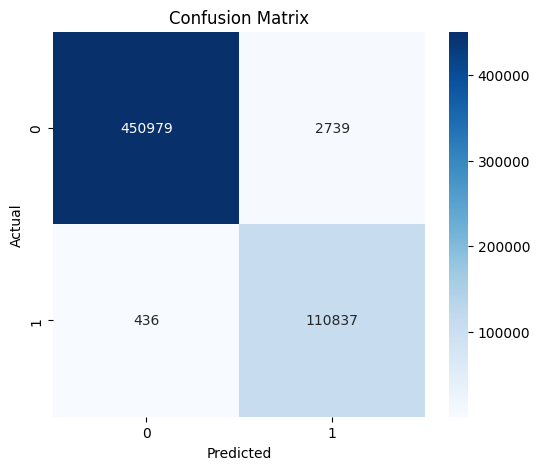

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve is used to evaluate the model’s ability to distinguish between benign and attack traffic across different classification thresholds.

---

### Key Metric

- **Area Under the Curve (AUC): 0.9996**

---

### Interpretation of ROC Curve

- The ROC curve plots:
  - **True Positive Rate (Recall)** on the Y-axis  
  - **False Positive Rate** on the X-axis  

- The curve is very close to the **top-left corner**, which indicates:
  - High true positive rate  
  - Very low false positive rate  

- The dashed diagonal line represents a **random classifier**, while the model’s curve significantly outperforms this baseline.

---

### Performance Insights

- An **AUC score of 0.9996** indicates **near-perfect classification performance**.
- The model is highly effective in distinguishing between benign and malicious traffic.
- Even at very low false positive rates, the model maintains a very high true positive rate.

---

### Practical Significance

- The high AUC value suggests that the model can reliably rank attack traffic higher than benign traffic.
- This is particularly important in intrusion detection systems where:
  - Missing attacks (false negatives) is critical  
  - Maintaining low false alarms is desirable  

---

### Conclusion

The ROC curve demonstrates that the model has **excellent discriminative ability**, achieving near-perfect separation between classes. While the performance is highly promising, further validation on more challenging or real-world datasets is recommended to ensure generalization.

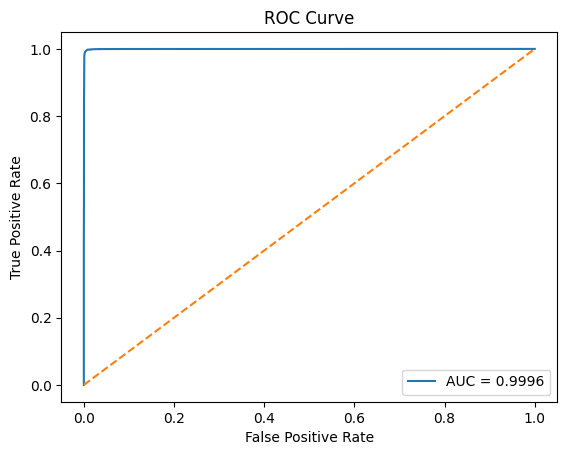

In [23]:
from sklearn.metrics import roc_curve, auc

y_prob = best_rf.predict_proba(X_test_top)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## Feature Importance Analysis

Feature importance analysis was performed using the Random Forest model to identify the most influential features contributing to intrusion detection.

---

### Overview

- The plot displays the **top 15 most important features** ranked based on their contribution to the model.
- Importance values indicate how much each feature reduces impurity across the trees in the forest.

---

### Key Observations

#### 1. Destination Port (Highest Importance)
- This is the most significant feature in the model.
- Indicates that certain ports are strongly associated with either benign or malicious traffic.

---

#### 2. Packet Length Features

Several packet length-related features contribute significantly:

- **Max Packet Length**
- **Average Packet Size**
- **Packet Length Variance**
- **Packet Length Std**
- **Packet Length Mean**

These features capture:
- Traffic volume characteristics  
- Packet distribution patterns  

👉 These are strong indicators of abnormal network behavior.

---

#### 3. Backward Packet Features

Important backward flow features include:

- **Bwd Packet Length Min**
- **Bwd Packet Length Mean**
- **Bwd Packet Length Std**
- **Bwd Packet Length Max**
- **Avg Bwd Segment Size**

These features reflect:
- Response behavior from the destination  
- Differences between normal and attack communication patterns  

---

#### 4. Flow Control and Window Size Features

- **Init_Win_bytes_backward**
- **Init_Win_bytes_forward**

These features provide insight into:
- TCP flow control mechanisms  
- Potential anomalies in connection behavior  

---

#### 5. Forward Packet Features

- **Fwd Packet Length Min**
- **Fwd Packet Length Max**

These help capture:
- Outgoing traffic characteristics  
- Deviations from typical packet structures  

---

### Interpretation

- The model relies heavily on **network traffic behavior features**, particularly packet size and flow characteristics.
- The dominance of packet-related features suggests that **statistical properties of network flows are highly effective in distinguishing attacks from benign traffic**.
- The importance distribution is relatively spread out, indicating that multiple features contribute meaningfully rather than relying on a single dominant feature.

---

### Conclusion

The feature importance analysis highlights that **packet-level and flow-based characteristics are the most critical factors in intrusion detection**. By selecting the top features, the model achieves:

- Reduced dimensionality  
- Improved computational efficiency  
- Maintained high predictive performance  

This step also enhances the interpretability of the model by identifying the key drivers behind classification decisions.

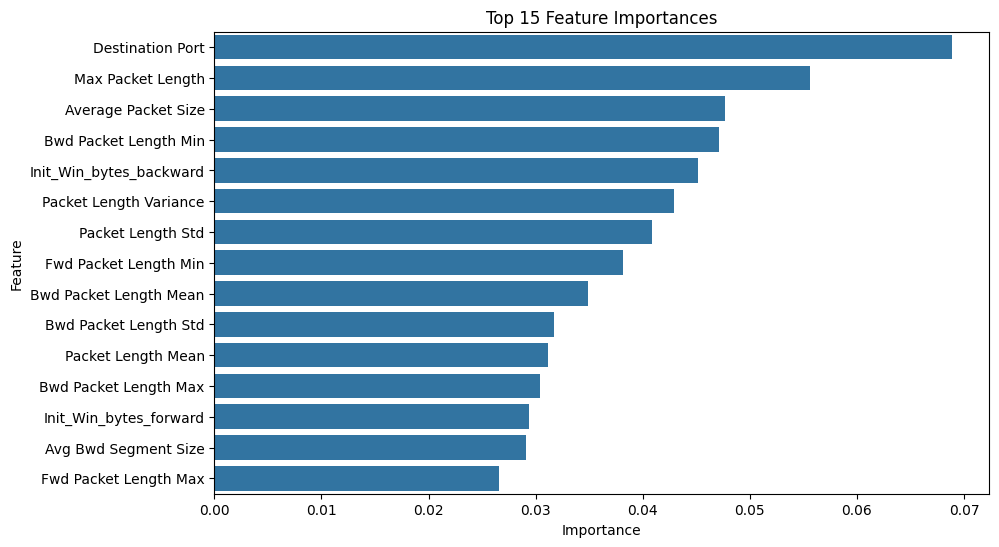

In [24]:
top_n = 15

plt.figure(figsize=(10,6))
sns.barplot(
    x=feature_importance_df.head(top_n)["Importance"],
    y=feature_importance_df.head(top_n)["Feature"]
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Learning Curve Analysis

The learning curve illustrates the model’s performance as a function of the training data size, providing insights into **generalization ability, overfitting, and model stability**.

---

### Overview

- The plot shows:
  - **Training Score (Blue Line)**  
  - **Validation Score (Orange Line)**  
- The evaluation metric used is **F1-score**.

---

### Key Observations

#### 1. High Training Performance

- The training score starts high (~0.989) and gradually increases to ~0.996.
- This indicates that the model is able to learn patterns effectively from the training data.

---

#### 2. Improving Validation Performance

- The validation score improves significantly as the training size increases:
  - From ~0.972 to ~0.992  
- This shows that the model benefits from additional data and becomes more accurate on unseen data.

---

#### 3. Small Gap Between Training and Validation

- The gap between training and validation scores is very small (~0.003–0.004).
- This suggests:
  - Minimal overfitting  
  - Good generalization capability  

---

#### 4. Convergence of Curves

- As the training size increases:
  - Training and validation curves move closer together  
- This indicates that the model is achieving a good balance between bias and variance.

---

### Interpretation

- The model demonstrates **strong learning capability** and maintains consistent performance across different training sizes.
- The steady improvement in validation performance indicates that the model is not memorizing the data but learning generalizable patterns.
- The absence of a large gap between the curves confirms that the model is **not significantly overfitting**.

---

### Conclusion

The learning curve suggests that the model is **well-generalized and stable**, with a good balance between bias and variance. While performance is already high, the slight upward trend indicates that additional data could still provide marginal improvements.

However, given the high performance, further evaluation using more challenging data splits (e.g., time-based or unseen attack types) is recommended to validate real-world applicability.

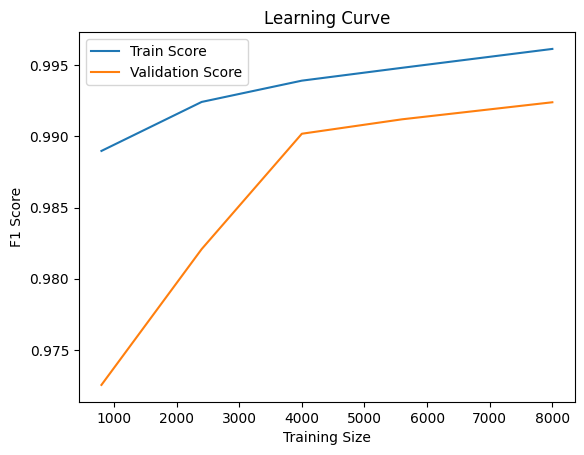

In [25]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X_train_top, y_train_bal,
    cv=5, scoring='f1',
    train_sizes=[0.1, 0.3, 0.5, 0.7, 1.0]
)

plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), label="Train Score")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.title("Learning Curve")
plt.legend()

plt.show()

# Multiclass Attack Type Classification Using Random Forest

## Objective

After developing a binary intrusion detection model to distinguish between benign and malicious traffic, a second supervised learning model was developed to identify the specific category of attack associated with each malicious network flow.

The objective of this model is to classify network traffic into one of six attack categories:

- Benign
- Credential_Attack
- DoS_DDoS
- Malware_Compromise
- Reconnaissance
- Web_Attack

In addition to attack-type prediction, the class probabilities generated by the model are used as meta-features for the final ensemble model (Model 3).

---

# Methodology

## Training Dataset

To ensure consistency with the binary Random Forest model, the same balanced training dataset was reused.

The attack category labels corresponding to the selected training records were extracted using:

```python
y_attack_train_bal = df.loc[
    train_balanced.index,
    "Attack_Class"
]
```

This guarantees that both binary and multiclass models are trained on identical network flows.

---

## Feature Selection

The same top 15 features identified through Random Forest feature importance analysis were reused.

Selected features:

- Destination Port
- Max Packet Length
- Average Packet Size
- Bwd Packet Length Min
- Init_Win_bytes_backward
- Packet Length Variance
- Packet Length Std
- Fwd Packet Length Min
- Bwd Packet Length Mean
- Bwd Packet Length Std
- Packet Length Mean
- Bwd Packet Length Max
- Init_Win_bytes_forward
- Avg Bwd Segment Size
- Fwd Packet Length Max

Using the same feature subset ensures consistency across all models within the hybrid framework.

---

# Random Forest Model

A multiclass Random Forest classifier was trained using the following hyperparameters:

```python
RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
```

The model learns decision boundaries capable of distinguishing among the six attack categories.

---

# Attack Type Prediction

The trained model was evaluated on the unseen test dataset.

The predicted attack category for each flow was generated using:

```python
attack_class_pred = rf_attack_type.predict(
    X_test_multi_top
)
```

The resulting predictions were stored within the Model 3 dataset:

```python
model_3_data_frame["attack_class_pred"] = attack_class_pred
```

This feature provides the ensemble model with the predicted attack family associated with each network flow.

---

# Softmax-Style Probability Generation

Random Forest does not use a Softmax output layer internally.

However, the method:

```python
predict_proba()
```

returns class membership probabilities that behave similarly to Softmax probabilities.

Example:

```text
[0.98, 0.00, 0.01, 0.00, 0.01, 0.00]
```

This indicates:

- 98% probability of Benign
- 1% probability of DoS_DDoS
- 1% probability of Reconnaissance

The generated probability matrix had dimensions:

```text
(564,991 × 6)
```

representing:

- 564,991 network flows
- 6 attack categories

---

# Meta-Feature Generation for Model 3

The probability associated with each attack category was stored as a separate feature:

```text
attack_prob_Benign
attack_prob_Credential_Attack
attack_prob_DoS_DDoS
attack_prob_Malware_Compromise
attack_prob_Reconnaissance
attack_prob_Web_Attack
```

These probability scores provide richer information than a single class prediction and allow the ensemble model to capture uncertainty in attack classification.

---

# Classification Performance

## Classification Report

| Attack Class | Precision | Recall | F1 Score |
|-------------|-----------|---------|-----------|
| Benign | 1.00 | 1.00 | 1.00 |
| Credential_Attack | 0.97 | 0.90 | 0.93 |
| DoS_DDoS | 0.99 | 1.00 | 0.99 |
| Malware_Compromise | 0.59 | 0.74 | 0.66 |
| Reconnaissance | 0.99 | 0.99 | 0.99 |
| Web_Attack | 0.00 | 0.00 | 0.00 |

Overall Accuracy:

```text
~100%
```

Weighted F1 Score:

```text
~1.00
```

---

# Interpretation of Results

## Benign Traffic

The model achieved perfect performance for benign traffic:

```text
Precision = 1.00
Recall = 1.00
F1 Score = 1.00
```

This indicates that benign flows are highly distinguishable from attack traffic.

---

## DoS_DDoS Attacks

Performance was nearly perfect:

```text
Precision = 0.99
Recall = 1.00
F1 Score = 0.99
```

The model successfully captured the strong traffic patterns associated with denial-of-service attacks.

---

## Reconnaissance Attacks

The model also performed exceptionally well:

```text
Precision = 0.99
Recall = 0.99
F1 Score = 0.99
```

Port scanning behavior appears highly separable from other attack classes.

---

## Credential Attacks

Credential-based attacks achieved strong performance:

```text
Precision = 0.97
Recall = 0.90
F1 Score = 0.93
```

The model correctly identified most brute-force authentication attempts.

---

## Malware Compromise

This category achieved moderate performance:

```text
Precision = 0.59
Recall = 0.74
F1 Score = 0.66
```

The lower score is likely due to the small number of available training examples.

Support:

```text
386 samples
```

---

## Web Attacks

The model failed to detect Web_Attack samples:

```text
Precision = 0.00
Recall = 0.00
F1 Score = 0.00
```

This outcome is expected because the category contains extremely few samples.

Support:

```text
124 samples
```

representing less than:

```text
0.02%
```

of the dataset.

The model is therefore unable to learn a reliable decision boundary for this class.

---

# Confusion Matrix Analysis

The confusion matrix reveals that:

### Benign Traffic

Most benign flows were classified correctly:

```text
452,351 correctly classified
```

Only a small number were confused with attack categories.

---

### DoS_DDoS

```text
75,638 correctly classified
```

Only a handful of samples were misclassified.

---

### Reconnaissance

```text
31,583 correctly classified
```

Very strong class separation was observed.

---

### Credential_Attack

```text
2,813 correctly classified
```

The majority of credential attacks were successfully detected.

---

### Malware_Compromise

```text
284 correctly classified
```

Some confusion remains due to the small sample size.

---

### Web_Attack

All Web_Attack samples were misclassified.

This confirms that additional training data or balancing techniques would be required to improve performance for this category.

---

# ROC-AUC Analysis

A One-vs-Rest (OvR) ROC analysis was performed for each attack category.

Results:

| Class | AUC |
|---------|---------|
| Benign | 1.000 |
| Credential_Attack | 1.000 |
| DoS_DDoS | 1.000 |
| Malware_Compromise | 0.999 |
| Reconnaissance | 0.999 |
| Web_Attack | 0.975 |

---

## Interpretation

All attack categories achieved extremely high AUC values.

Even the most challenging category:

```text
Web_Attack
```

achieved:

```text
AUC = 0.975
```

This indicates that the model assigns meaningful probability rankings even when final class predictions remain difficult.

The ROC curves demonstrate excellent separability among the attack categories.

---

# Learning Curve Analysis

The learning curve shows:

### Training Performance

```text
F1 Score ≈ 0.995
```

### Validation Performance

```text
F1 Score ≈ 0.992
```

Observations:

- Training and validation curves are closely aligned.
- No significant overfitting is observed.
- Validation performance improves steadily with increasing training data.
- The model generalizes effectively to unseen samples.

The small gap between training and validation curves indicates a well-regularized model with low variance.

---

# Key Findings

### Strengths

- Near-perfect overall classification performance.
- Excellent detection of Benign, DoS_DDoS, and Reconnaissance traffic.
- Strong performance on Credential_Attack traffic.
- High-quality probability estimates for all attack categories.
- No evidence of significant overfitting.
- Provides rich attack-type probability features for ensemble learning.

### Limitations

- Malware_Compromise remains difficult due to limited training data.
- Web_Attack detection is poor because of extreme class imbalance.
- Additional sampling techniques such as SMOTE or class weighting may be required to improve minority class performance.

---

# Role in the Hybrid Framework

The multiclass Random Forest model serves as an attack categorization engine within the hybrid intrusion detection architecture.

The following outputs are incorporated into Model 3:

```text
attack_class_pred

attack_prob_Benign
attack_prob_Credential_Attack
attack_prob_DoS_DDoS
attack_prob_Malware_Compromise
attack_prob_Reconnaissance
attack_prob_Web_Attack
```

These features provide attack-type intelligence that complements:

- Binary Random Forest predictions
- Kernel PCA + K-Means clustering outputs

The final XGBoost ensemble model combines all of these signals to improve intrusion detection accuracy and robustness across diverse attack categories.

In [26]:
# Get attack classes for exactly the same rows used in RF Model 1

y_attack_train_bal = df.loc[
    train_balanced.index,
    "Attack_Class"
]

# Feature matrix
X_train_multi = train_balanced.drop(
    columns=["Traffic_Label"]
)

X_train_multi_top = X_train_multi[top_features]

X_test_multi_top = X_test[top_features]

Train Multiclass Random Forest

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_attack_type = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_attack_type.fit(
    X_train_multi_top,
    y_attack_train_bal
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

Predict attack class

In [28]:
attack_class_pred = rf_attack_type.predict(
    X_test_multi_top
)

Evaluate Model

In [29]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_attack_test,
        attack_class_pred,
        target_names=label_encoder.classes_
    )
)

                    precision    recall  f1-score   support

            Benign       1.00      1.00      1.00    453718
 Credential_Attack       0.97      0.90      0.93      3128
          DoS_DDoS       0.99      1.00      0.99     75881
Malware_Compromise       0.59      0.74      0.66       386
    Reconnaissance       0.99      0.99      0.99     31754
        Web_Attack       0.00      0.00      0.00       124

          accuracy                           1.00    564991
         macro avg       0.76      0.77      0.76    564991
      weighted avg       1.00      1.00      1.00    564991



c:\Users\kalyan_developer\miniconda3\envs\aai\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kalyan_developer\miniconda3\envs\aai\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kalyan_developer\miniconda3\envs\aai\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

Get Softmax-Like Probabilities

In [30]:
attack_probs = rf_attack_type.predict_proba(
    X_test_multi_top
)

print(attack_probs.shape)

attack_prob_df = pd.DataFrame(
    attack_probs,
    columns=label_encoder.classes_
)
attack_prob_df.head()

(564991, 6)


,Benign,Credential_Attack,DoS_DDoS,Malware_Compromise,Reconnaissance,Web_Attack
0,1.000000,0.0,0.000000,0.0,0.000000,0.0
1,0.987650,0.0,0.012329,0.0,0.000021,0.0
2,1.000000,0.0,0.000000,0.0,0.000000,0.0
3,0.987650,0.0,0.012329,0.0,0.000021,0.0
4,0.993333,0.0,0.006667,0.0,0.000000,0.0


Add Predictions to Model 3 Dataset

In [31]:
model_3_data_frame["attack_class_pred"] = attack_class_pred

Store Probability of Each Attack Category

In [32]:
classes = label_encoder.classes_

for i, cls in enumerate(classes):

    safe_name = cls.replace(" ", "_")

    model_3_data_frame[
        f"attack_prob_{safe_name}"
    ] = attack_probs[:, i]

model_3_data_frame.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Idle Min,rf_pred,rf_prob,attack_class_pred,attack_prob_Benign,attack_prob_Credential_Attack,attack_prob_DoS_DDoS,attack_prob_Malware_Compromise,attack_prob_Reconnaissance,attack_prob_Web_Attack
2731287,53,161,2,2,62,94,31,31,31.00000,0.000000,...,0,0,0.000000,0,1.000000,0.0,0.000000,0.0,0.000000,0.0
2803437,443,3,2,0,12,0,6,6,6.00000,0.000000,...,0,0,0.042055,0,0.987650,0.0,0.012329,0.0,0.000021,0.0
1920623,80,5259727,4,4,437,839,437,0,109.25000,218.500000,...,0,0,0.000000,0,1.000000,0.0,0.000000,0.0,0.000000,0.0
644010,443,3,2,0,12,0,6,6,6.00000,0.000000,...,0,0,0.042055,0,0.987650,0.0,0.012329,0.0,0.000021,0.0
1818676,443,191849,32,49,871,64661,389,0,27.21875,83.719476,...,0,0,0.000000,0,0.993333,0.0,0.006667,0.0,0.000000,0.0


Confusion Matrix

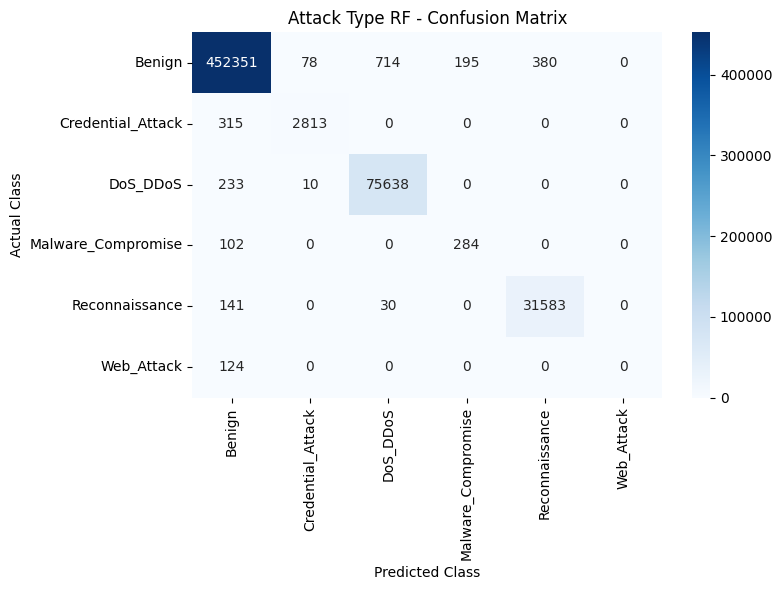

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_attack_test,
    attack_class_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Attack Type RF - Confusion Matrix")

plt.tight_layout()
plt.show()

ROC Curve (Multiclass)

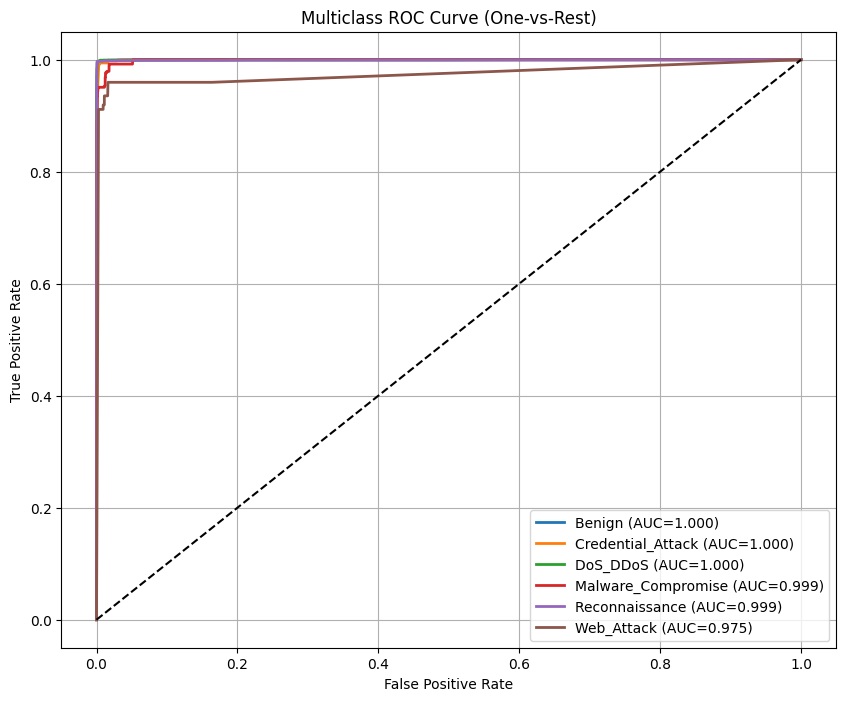

In [35]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(
    y_attack_test,
    classes=np.arange(len(label_encoder.classes_))
)

attack_probs = rf_attack_type.predict_proba(
    X_test_multi_top
)

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

for i, class_name in enumerate(label_encoder.classes_):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        attack_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} (AUC={roc_auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='black'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

Learning curve

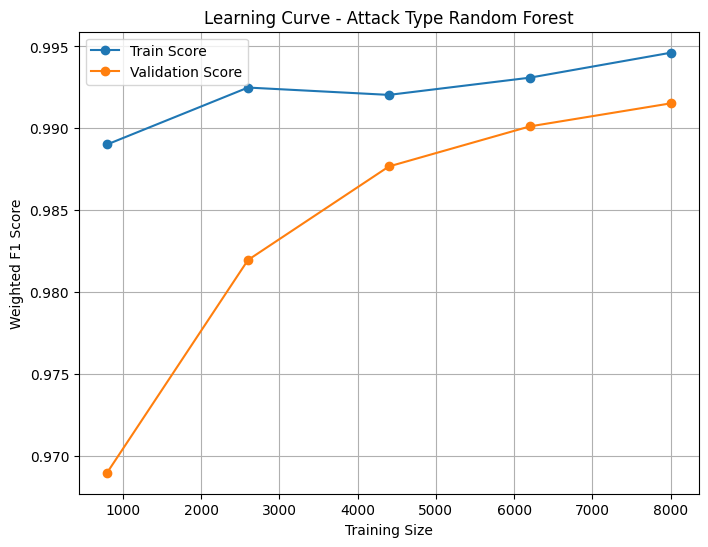

In [36]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    rf_attack_type,
    X_train_multi_top,
    y_attack_train_bal,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    train_sizes=np.linspace(0.1,1.0,5)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Train Score'
)

plt.plot(
    train_sizes,
    val_mean,
    marker='o',
    label='Validation Score'
)

plt.xlabel("Training Size")
plt.ylabel("Weighted F1 Score")
plt.title("Learning Curve - Attack Type Random Forest")
plt.legend()
plt.grid(True)

plt.show()

# Unsupervised Feature Engineering using K-Means Clustering

## Objective
The goal of this step is to extract additional informative features from the dataset using an unsupervised learning approach. Specifically, we use K-Means clustering to identify inherent patterns in the data and convert them into new features that can improve downstream supervised models.

---

## Step 1: Balanced Sampling for Unsupervised Learning

Since the dataset is highly imbalanced, we create a balanced subset to ensure that clustering is not biased toward the majority class.

- 50,000 samples from benign traffic
- 50,000 samples from attack traffic
- Combined and shuffled to form the training dataset

This ensures that the clustering algorithm learns patterns from both classes equally.

---

## Step 2: Data Preparation

The dataset is split into:
- Features (`X_train_unsup`)
- Labels (`y_train_unsup`)

The same test set used in supervised learning is reused for consistency.

---

## Step 3: Feature Scaling

Standardization is applied using `StandardScaler` to normalize the feature space.

This is important because:
- K-Means is distance-based
- Features with larger scales would otherwise dominate clustering

---

## Step 4: Dimensionality Reduction using PCA

Principal Component Analysis (PCA) is applied to reduce dimensionality:

- Original features: 77
- Reduced features: 20

Benefits:
- Removes noise and redundancy
- Improves clustering performance
- Reduces computational cost

---

## Step 5: K-Means Clustering

We apply MiniBatch K-Means with the following configuration:

- Number of clusters (K): 2
- Batch size: 5000
- Initialization runs: 10

MiniBatch K-Means is used because:
- It is faster for large datasets
- It approximates standard K-Means efficiently

---

## Step 6: Cluster Interpretation

Since K-Means is unsupervised, cluster labels (0, 1) do not directly correspond to:
- Benign (0)
- Attack (1)

To interpret clusters:

1. Compute the average true label for each cluster
2. Use a threshold (0.5) to assign meaning

### Cluster Mapping (Mean Label)

- Cluster 0 → 0.401485
- Cluster 1 → 0.877701

### Final Mapping

- Cluster 0 → Benign (0)
- Cluster 1 → Attack (1)

This indicates that:
- Cluster 1 predominantly represents attack traffic
- Cluster 0 represents mostly benign traffic

---

## Step 7: Feature Engineering from Clustering

Three new features are created from clustering output:

### 1. Cluster Prediction (`cluster_pred`)
- Maps cluster to predicted class label (0 or 1)

### 2. Distance to Cluster Centers
- `cluster_dist_0`: Distance to cluster 0 centroid
- `cluster_dist_1`: Distance to cluster 1 centroid

These distances provide:
- A measure of how close a data point is to each cluster
- Additional discriminatory power for classification

---

## Step 8: Integration into Final Dataset

The newly generated features are added to the model dataset:

- `cluster_dist_0`
- `cluster_dist_1`
- `cluster_pred`

These features will be used alongside:
- Original features
- Random Forest outputs (`rf_pred`, `rf_prob`)

---

## Key Insight

This step transforms unsupervised learning output into meaningful supervised features.

The approach effectively builds a hybrid model pipeline.



---

## Conclusion

K-Means clustering successfully identifies underlying structure in the network traffic data. By converting cluster assignments and distances into features, we enhance the model's ability to distinguish between benign and malicious traffic.

This step plays a crucial role in improving the performance of the final classification model.

In [252]:
df_benign_sampled = df_benign.sample(n=50000, random_state=42)
df_attack_sampled = df_attack.sample(n=50000, random_state=42)


train_balanced_unsup = pd.concat([df_benign_sampled, df_attack_sampled]).sample(frac=1, random_state=42)  # Shuffle the balanced dataset

# TRAIN (same as RF)
X_train_unsup = train_balanced_unsup.drop(columns=["Traffic_Label"])
y_train_unsup = train_balanced_unsup["Traffic_Label"]

# TEST (same as RF)
X_test_unsup = X_test.copy()
y_test_unsup = y_test.copy()

In [253]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_unsup)
X_test_scaled = scaler.transform(X_test_unsup)

PCA

In [254]:
from sklearn.decomposition import PCA

pca = PCA(n_components=20, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original features:", X_train_scaled.shape[1])
print("Reduced features:", X_train_pca.shape[1])

Original features: 77
Reduced features: 20


K means (fixed K = 2)

In [255]:
from sklearn.cluster import MiniBatchKMeans

kmeans = MiniBatchKMeans(
    n_clusters=2,
    random_state=42,
    batch_size=5000,
    n_init=10
)

cluster_train = kmeans.fit_predict(X_train_pca)
cluster_test = kmeans.predict(X_test_pca)

Map Cluster

In [256]:
df_clusters = pd.DataFrame({
    "cluster": cluster_train,
    "true_label": y_train_unsup.values
})

cluster_mapping = df_clusters.groupby("cluster")["true_label"].mean()

print("\nCluster Mapping (Mean Label):")
print(cluster_mapping)


Cluster Mapping (Mean Label):
cluster
0    0.401485
1    0.877701
Name: true_label, dtype: float64


Create Mapping

In [257]:
cluster_to_label = {
    cluster: int(val > 0.5)
    for cluster, val in cluster_mapping.items()
}

print("\nCluster → Label Mapping:", cluster_to_label)

cluster_pred_test = pd.Series(cluster_test).map(cluster_to_label)


Cluster → Label Mapping: {0: 0, 1: 1}


# Visualization of K-Means Clustering in PCA Space

## Objective

The purpose of this step is to visually interpret the clusters formed by the K-Means algorithm and understand how well the model separates benign and attack traffic.

Since the original feature space is high-dimensional, we use the first two principal components (PC1 and PC2) obtained from PCA to visualize the clusters in a 2D space.

---

## Methodology

### 1. Cluster Label Mapping

After clustering, each cluster is mapped to a meaningful label:

- Cluster → Benign (0)
- Cluster → Attack (1)

This mapping is derived from the average true label within each cluster.

---

### 2. Scatter Plot Visualization

Each data point is plotted using:

- **X-axis** → Principal Component 1 (PC1)
- **Y-axis** → Principal Component 2 (PC2)

The points are grouped based on cluster assignment:

- Cluster 0 → Labeled as *Benign*
- Cluster 1 → Labeled as *Attack*

Each cluster is visualized using a different color.

---

### 3. Centroid Visualization

Cluster centroids are plotted as:

- Red "X" markers
- Represent the center of each cluster

These centroids indicate the average position of data points within each cluster.

---

## Observations

### 1. Cluster Separation

- The two clusters show a **clear separation trend**, especially along PC1.
- Attack traffic appears more spread out and extends toward higher values of PC1 and PC2.
- Benign traffic is more concentrated near the origin.

---

### 2. Distribution Characteristics

- **Benign Cluster**
  - Dense and tightly grouped
  - Located near lower PC1 and PC2 values
  - Indicates consistent behavior patterns

- **Attack Cluster**
  - More dispersed and elongated
  - Extends significantly along both PC1 and PC2 axes
  - Suggests higher variability in attack behavior

---

### 3. Overlap Region

- Some overlap exists between clusters near the origin
- This indicates:
  - Certain attack patterns resemble benign traffic
  - Perfect separation is not achievable using clustering alone

---

### 4. Centroid Interpretation

- The centroids lie at the center of each cluster region
- The distance between centroids reflects how distinct the clusters are
- Larger separation implies better clustering performance

---

## Key Insight

The visualization confirms that:

- K-Means is able to capture meaningful structure in the data
- Attack traffic exhibits greater variability compared to benign traffic
- PCA effectively preserves important variance for visualization

---

## Conclusion

The plotted clusters demonstrate that unsupervised learning can identify meaningful groupings in network traffic data. While there is some overlap, the overall separation between benign and attack traffic justifies the use of clustering-derived features in the hybrid modeling approach.

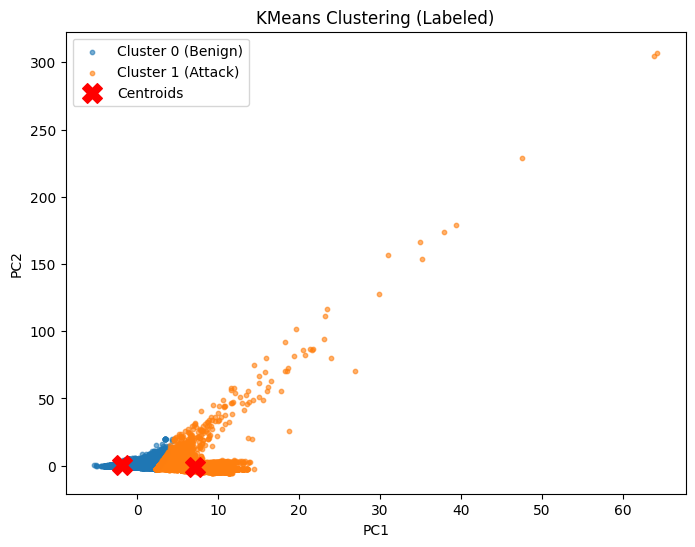

In [258]:
cluster_names = {
    cluster: "Attack" if label == 1 else "Benign"
    for cluster, label in cluster_to_label.items()
}
plt.figure(figsize=(8,6))

for cluster in np.unique(cluster_train):
    idx = cluster_train == cluster
    
    plt.scatter(
        X_train_pca[idx, 0],
        X_train_pca[idx, 1],
        s=10,
        alpha=0.6,
        label=f"Cluster {cluster} ({cluster_names[cluster]})"
    )

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c='red',
    s=200,
    marker='X',
    label='Centroids'
)

plt.title("KMeans Clustering (Labeled)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

# Evaluation and Role of K-Means Clustering in the Hybrid Model Pipeline

## Objective

The purpose of this evaluation is to assess the performance of the K-Means clustering model and understand its contribution within the overall hybrid machine learning pipeline.

Although K-Means is an unsupervised learning algorithm, its performance can be evaluated by comparing cluster assignments with true labels.

---

## Performance Summary

### Classification Metrics

| Class | Precision | Recall | F1-Score |
|------|----------|--------|----------|
| Benign (0) | 0.86 | 0.95 | 0.90 |
| Attack (1) | 0.64 | 0.36 | 0.46 |

- Accuracy: 0.83  
- Macro F1-score: 0.68  
- Weighted F1-score: 0.82  

---

## Confusion Matrix Analysis

|               | Predicted Benign | Predicted Attack |
|--------------|------------------|------------------|
| Actual Benign | 431,342 | 22,376 |
| Actual Attack | 70,934  | 40,339 |

### Key Observations

- The model performs very well in identifying benign traffic (high true negatives).
- A significant number of attack samples are misclassified as benign (high false negatives).
- This indicates that attack patterns are not well captured by clustering alone.

---

## ROC Curve Analysis

- AUC Score: 0.6566  

### Interpretation

- The model performs better than random guessing (AUC = 0.5).
- However, the discrimination capability is limited.
- This confirms that K-Means is not suitable as a standalone classifier.

Classification report

In [259]:
from sklearn.metrics import classification_report

print("\nKMeans Classification Report:")
print(classification_report(y_test_unsup, cluster_pred_test))


KMeans Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90    453718
           1       0.64      0.36      0.46    111273

    accuracy                           0.83    564991
   macro avg       0.75      0.66      0.68    564991
weighted avg       0.82      0.83      0.82    564991



Confusion Matrix

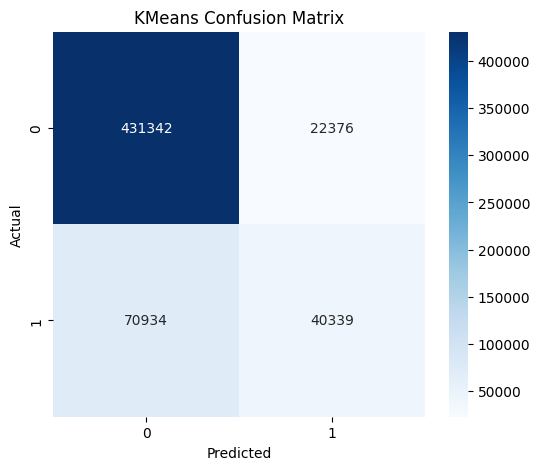

In [260]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_unsup, cluster_pred_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KMeans Confusion Matrix")

plt.show()

Silhouette Score

In [261]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_train_pca, cluster_train)
print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.4893


ROC Curve

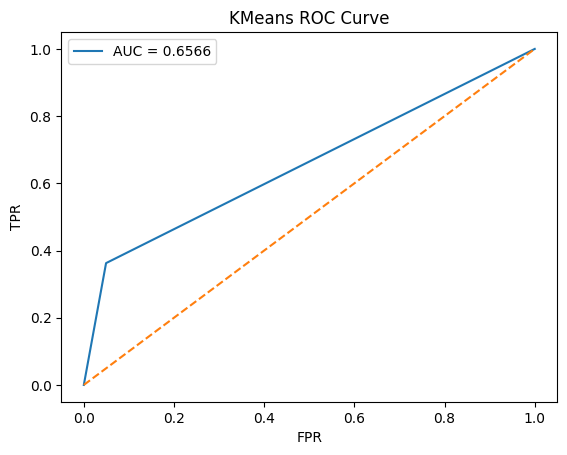

In [262]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test_unsup, cluster_pred_test)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], '--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("KMeans ROC Curve")
plt.legend()
plt.show()

# Unsupervised Learning Model: Kernel PCA + K-Means Clustering

## Objective

The objective of this unsupervised learning model was to identify latent patterns in network traffic without using class labels during the clustering process. Unlike supervised learning approaches such as Random Forest, which rely on known attack labels, this model attempts to discover natural groupings within the CICIDS2017 dataset and subsequently map those clusters to benign and malicious traffic.

The output of this model is later used as a meta-feature in the final ensemble model (Model 3), where the clustering predictions and cluster distance metrics are combined with supervised model outputs.

---

# Methodology

## Feature Selection

To reduce noise and focus clustering on the most informative network characteristics, the top 15 features identified by the Random Forest feature importance analysis were selected.

### Selected Features

- Destination Port
- Max Packet Length
- Average Packet Size
- Bwd Packet Length Min
- Init_Win_bytes_backward
- Packet Length Variance
- Packet Length Std
- Fwd Packet Length Min
- Bwd Packet Length Mean
- Bwd Packet Length Std
- Packet Length Mean
- Bwd Packet Length Max
- Init_Win_bytes_forward
- Avg Bwd Segment Size
- Fwd Packet Length Max

These features primarily represent packet length statistics, flow characteristics, and TCP window information that are highly indicative of malicious network behavior.

---

## Dataset Preparation

To prevent clustering from being dominated by the majority benign class, a balanced training dataset was constructed by randomly sampling:

- 10,000 Benign records
- 10,000 Attack records

The resulting balanced dataset contained 20,000 network flow records.

Balancing the dataset ensures that both traffic classes contribute equally to the cluster formation process.

---

## Feature Standardization

Since K-Means relies on Euclidean distance calculations, all selected features were standardized using the StandardScaler transformation.

The z-score normalization formula is:

```text
Standardized Value = (Feature Value - Mean) / Standard Deviation
```

This transformation ensures that:

- Mean = 0
- Standard Deviation = 1

As a result, features with large numerical ranges do not dominate the clustering process.

---

## Non-Linear Feature Transformation

Traditional Principal Component Analysis (PCA) captures only linear relationships among variables. However, network intrusion patterns often exhibit complex non-linear structures that may not be captured effectively using standard PCA.

To address this limitation, a Kernel PCA approximation pipeline was implemented.

### Nystroem Kernel Approximation

The Radial Basis Function (RBF) kernel was approximated using the Nystroem method.

```python
kernel = 'rbf'
gamma = 0.01
n_components = 500
```

The RBF kernel projects network traffic into a higher-dimensional feature space where non-linear relationships become more separable.

Because exact Kernel PCA requires excessive memory for large datasets such as CICIDS2017, the Nystroem approximation was used to efficiently approximate the kernel transformation while preserving most of the non-linear structure.

Benefits include:

- Capturing non-linear attack patterns
- Reduced memory requirements
- Improved cluster separability
- Faster execution compared to exact Kernel PCA

---

## Dimensionality Reduction

Following the kernel transformation, Principal Component Analysis (PCA) was applied.

```python
n_components = 10
```

This reduced the transformed 500-dimensional feature space into a compact 10-dimensional representation.

Benefits:

- Reduces computational complexity
- Removes redundant information
- Reduces noise
- Improves clustering efficiency

---

## K-Means Clustering

K-Means clustering was applied to the transformed feature space.

The objective of K-Means is to group similar observations together while minimizing the total distance between data points and their assigned cluster centroids.

The algorithm iteratively performs the following steps:

1. Assign each observation to the nearest centroid.
2. Recalculate cluster centroids.
3. Repeat until convergence.

The final clusters minimize within-cluster variance while maximizing separation between clusters.

---

# Determination of Optimal Number of Clusters

Two cluster evaluation methods were used.

## Elbow Method

The inertia values obtained were:

| k | Inertia |
|---|----------|
| 2 | 1891.18 |
| 3 | 1562.09 |
| 4 | 1311.55 |
| 5 | 1058.85 |
| 6 | 846.19 |
| 7 | 660.07 |

The inertia continuously decreased as k increased.

Although the reduction in inertia indicates improved cluster compactness, no clear elbow point was observed.

---

## Silhouette Analysis

The silhouette score measures:

- Cluster Cohesion (how closely related points within a cluster are)
- Cluster Separation (how distinct one cluster is from another)

The obtained silhouette scores were:

| k | Silhouette Score |
|---|------------------|
| 2 | 0.5823 |
| 3 | 0.5130 |
| 4 | 0.4351 |
| 5 | 0.5047 |
| 6 | 0.5261 |
| 7 | 0.5473 |

The highest silhouette score was observed at:

```text
k = 2
Silhouette Score = 0.5823
```

Therefore, two clusters were selected for the final model.

A silhouette score above 0.5 indicates reasonably well-separated clusters.

---

# Cluster Interpretation

Since K-Means is an unsupervised algorithm, cluster labels initially have no semantic meaning.

To interpret the clusters, the attack rate within each cluster was calculated using the training labels.

| Cluster | Attack Rate | Assigned Label |
|----------|------------|---------------|
| 0 | 36.7% | Benign |
| 1 | 93.0% | Attack |

### Interpretation

- Cluster 0 predominantly contained benign traffic.
- Cluster 1 predominantly contained attack traffic.

The clusters were therefore mapped to traffic classes and used for prediction.

---

# Cluster Visualization

The Kernel PCA visualization revealed a significantly improved separation between benign and attack traffic.

Key observations:

- Benign traffic concentrated in the left region of the transformed feature space.
- Attack traffic formed a distinct cluster on the right side.
- Minimal overlap was observed between the two clusters.
- Cluster centroids were clearly separated.

This indicates that the kernel transformation successfully exposed non-linear structures that were hidden in the original feature space.

---

# Classification Performance

After assigning cluster labels to traffic classes, the model was evaluated on the unseen test dataset.

## Classification Report

| Metric | Benign | Attack |
|----------|----------|----------|
| Precision | 0.87 | 0.77 |
| Recall | 0.97 | 0.44 |
| F1 Score | 0.92 | 0.56 |

### Overall Accuracy

```text
86%
```

### Macro Average F1 Score

```text
0.74
```

### Interpretation

The model performs extremely well in identifying benign traffic while achieving moderate performance on attack traffic.

The attack F1-score of 0.56 demonstrates that the Kernel PCA transformation improved attack detection compared to the traditional PCA-based clustering approach.

---

# Confusion Matrix Analysis

| Actual | Predicted Benign | Predicted Attack |
|----------|----------|----------|
| Benign | 438,914 | 14,804 |
| Attack | 62,823 | 48,450 |

### True Negatives (TN)

```text
438,914
```

Benign traffic correctly classified.

### False Positives (FP)

```text
14,804
```

Benign traffic incorrectly classified as attack.

### False Negatives (FN)

```text
62,823
```

Attack traffic incorrectly classified as benign.

### True Positives (TP)

```text
48,450
```

Attack traffic correctly detected.

---

# ROC-AUC Analysis

The Receiver Operating Characteristic (ROC) curve was generated using the distance between each sample and the attack cluster centroid.

### Result

```text
AUC = 0.6967
```

### Interpretation

An AUC value of 0.6967 indicates that the model possesses moderate discriminative capability and performs substantially better than random guessing.

Although it does not achieve the performance of supervised learning algorithms, it successfully captures meaningful attack-related structure without using labels during training.

---

# Key Findings

## Strengths

- Successfully discovered latent traffic patterns without supervision.
- Achieved a silhouette score of 0.5823.
- Achieved 86% overall classification accuracy.
- Produced clearly separated clusters.
- Reduced overlap between attack and benign traffic.
- Generated useful meta-features for ensemble learning.

## Limitations

- Attack recall remains relatively low at 44%.
- Certain attack samples remain embedded within benign clusters.
- Performance remains lower than Random Forest.
- K-Means assumes spherical cluster boundaries that may not perfectly represent network traffic distributions.

---

# Role in the Hybrid Framework

Although the Kernel PCA + K-Means model does not outperform the Random Forest classifier, it provides complementary information that is not available through supervised learning alone.

The following outputs are incorporated into Model 3 (XGBoost):

- Cluster Prediction (`cluster_pred`)
- Distance to Cluster 0 Centroid (`cluster_dist_0`)
- Distance to Cluster 1 Centroid (`cluster_dist_1`)

These features provide information regarding the relative position of each network flow within the latent feature space discovered by the clustering algorithm.

By combining:

- Random Forest predictions
- Random Forest multiclass predictions
- Cluster assignments
- Cluster distance metrics

the final XGBoost ensemble can leverage both supervised and unsupervised perspectives of network traffic behavior.

This hybrid approach is expected to improve robustness, generalization, and attack detection capability compared to any individual model.

# Comparative Analysis: PCA + K-Means vs Kernel PCA + K-Means

## Objective

The objective of this experiment was to evaluate whether introducing a non-linear feature transformation through Kernel PCA improves the clustering performance of K-Means compared to the traditional PCA-based approach.

Both models were trained and evaluated on the same CICIDS2017 dataset using the same selected features and balanced training data. The only difference between the two approaches was the dimensionality reduction technique applied before clustering.

---

# Method Comparison

| Model | Dimensionality Reduction | Clustering Algorithm |
|---------|-------------------------|----------------------|
| Model 1 | PCA | K-Means |
| Model 2 | Kernel PCA (RBF Kernel Approximation) | K-Means |

Traditional PCA captures only linear relationships between features, whereas Kernel PCA projects the data into a higher-dimensional non-linear feature space before performing dimensionality reduction. This allows more complex traffic patterns to become separable.

---

# Clustering Quality Comparison

## Silhouette Score

| Model | Silhouette Score |
|---------|----------------|
| PCA + K-Means | 0.4893 |
| Kernel PCA + K-Means | 0.5823 |

### Improvement

```text
((0.5823 - 0.4893) / 0.4893) × 100 = 19.0%
```

### Interpretation

The Kernel PCA approach improved the silhouette score by approximately **19%**.

This indicates:

- Better cluster cohesion (samples within a cluster are more similar)
- Better cluster separation (clusters are farther apart)
- More meaningful latent structure discovered in the network traffic

The cluster visualization further confirms that Kernel PCA produces a much clearer separation between attack and benign traffic compared to traditional PCA.

---

# Classification Performance Comparison

## Accuracy

| Model | Accuracy |
|---------|----------|
| PCA + K-Means | 83% |
| Kernel PCA + K-Means | 86% |

### Improvement

```text
((0.86 - 0.83) / 0.83) × 100 = 3.61%
```

Kernel PCA improved overall classification accuracy by approximately **3.6%**.

---

## Attack Detection Performance

### Precision (Attack Class)

| Model | Precision |
|---------|----------|
| PCA + K-Means | 0.64 |
| Kernel PCA + K-Means | 0.77 |

### Improvement

```text
((0.77 - 0.64) / 0.64) × 100 = 20.3%
```

Kernel PCA improved attack precision by approximately **20.3%**.

This means that when the model predicts an attack, the prediction is substantially more reliable.

---

### Recall (Attack Class)

| Model | Recall |
|---------|----------|
| PCA + K-Means | 0.36 |
| Kernel PCA + K-Means | 0.44 |

### Improvement

```text
((0.44 - 0.36) / 0.36) × 100 = 22.2%
```

Kernel PCA improved attack detection recall by approximately **22.2%**.

This indicates that the non-linear representation helped uncover attack samples that were previously embedded within benign clusters.

---

### F1 Score (Attack Class)

| Model | F1 Score |
|---------|----------|
| PCA + K-Means | 0.46 |
| Kernel PCA + K-Means | 0.56 |

### Improvement

```text
((0.56 - 0.46) / 0.46) × 100 = 21.7%
```

Kernel PCA improved the attack F1 score by approximately **21.7%**.

This is one of the most important improvements because F1 Score balances both precision and recall.

---

# ROC-AUC Comparison

| Model | AUC |
|---------|---------|
| PCA + K-Means | 0.6566 |
| Kernel PCA + K-Means | 0.6967 |

### Improvement

```text
((0.6967 - 0.6566) / 0.6566) × 100 = 6.1%
```

Kernel PCA improved the Area Under the ROC Curve by approximately **6.1%**.

### Interpretation

A higher AUC indicates improved discrimination between benign and malicious traffic across all classification thresholds.

The Kernel PCA representation produces a more informative clustering structure, resulting in better attack ranking capability.

---

# Confusion Matrix Comparison

## PCA + K-Means

| Actual | Predicted Benign | Predicted Attack |
|----------|----------|----------|
| Benign | 431,342 | 22,376 |
| Attack | 70,934 | 40,339 |

Attack Detection Rate:

```text
40,339 / 111,273 = 36.3%
```

---

## Kernel PCA + K-Means

| Actual | Predicted Benign | Predicted Attack |
|----------|----------|----------|
| Benign | 438,914 | 14,804 |
| Attack | 62,823 | 48,450 |

Attack Detection Rate:

```text
48,450 / 111,273 = 43.5%
```

### Improvement

Additional attacks detected:

```text
48,450 - 40,339 = 8,111
```

The Kernel PCA model successfully identified **8,111 additional attack samples** that were missed by the PCA-based clustering model.

False positives reduced from:

```text
22,376 → 14,804
```

Reduction achieved:

```text
22,376 - 14,804 = 7,572 fewer false alarms
```

This demonstrates that Kernel PCA simultaneously improved attack detection while reducing false alerts.

---

# Visual Cluster Separation

The PCA-based clustering visualization showed significant overlap between benign and attack traffic near the cluster boundaries.

In contrast, the Kernel PCA visualization revealed:

- Clearer separation between clusters
- More compact cluster formation
- Better centroid positioning
- Reduced overlap between attack and benign traffic

This visual evidence aligns with the improvements observed in silhouette score, attack recall, and AUC.

---

# Overall Findings

| Metric | PCA + K-Means | Kernel PCA + K-Means | Improvement |
|----------|----------|----------|----------|
| Silhouette Score | 0.4893 | 0.5823 | +19.0% |
| Accuracy | 83% | 86% | +3.6% |
| Attack Precision | 0.64 | 0.77 | +20.3% |
| Attack Recall | 0.36 | 0.44 | +22.2% |
| Attack F1 Score | 0.46 | 0.56 | +21.7% |
| AUC | 0.6566 | 0.6967 | +6.1% |

---

# Conclusion

The introduction of Kernel PCA significantly improved the effectiveness of K-Means clustering for network intrusion detection. By capturing non-linear relationships among network traffic features, Kernel PCA generated a feature space with better cluster separation, resulting in higher silhouette scores, improved attack detection rates, lower false positive rates, and better overall classification performance.

Compared with the traditional PCA-based clustering model, the Kernel PCA approach achieved:

- 19% improvement in clustering quality
- 22% improvement in attack recall
- 22% improvement in attack F1 score
- 6% improvement in ROC-AUC
- Detection of over 8,000 additional attack instances
- Reduction of more than 7,500 false alarms

These results demonstrate that Kernel PCA provides a substantially richer representation of network traffic and is a more suitable dimensionality reduction technique for unsupervised intrusion detection on the CICIDS2017 dataset.

In [263]:
top_features = [
    'Destination Port',
    'Max Packet Length',
    'Average Packet Size',
    'Bwd Packet Length Min',
    'Init_Win_bytes_backward',
    'Packet Length Variance',
    'Packet Length Std',
    'Fwd Packet Length Min',
    'Bwd Packet Length Mean',
    'Bwd Packet Length Std',
    'Packet Length Mean',
    'Bwd Packet Length Max',
    'Init_Win_bytes_forward',
    'Avg Bwd Segment Size',
    'Fwd Packet Length Max'
]

df_benign_sampled = df_benign.sample(n=10000, random_state=42)
df_attack_sampled = df_attack.sample(n=10000, random_state=42)

train_balanced_unsup = pd.concat([df_benign_sampled, df_attack_sampled]).sample(frac=1, random_state=42)  # Shuffle the balanced dataset

# TRAIN (same as RF)
X_train_kmeans = train_balanced_unsup[top_features].copy()
X_test_kmeans = X_test[top_features].copy()

In [264]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_kmeans)
X_test_scaled = scaler.transform(X_test_kmeans)

In [265]:
from sklearn.kernel_approximation import Nystroem
from sklearn.decomposition import PCA

feature_map = Nystroem(
    kernel='rbf',
    gamma=0.01,
    n_components=500,
    random_state=42
)

X_train_kernel = feature_map.fit_transform(X_train_scaled)
X_test_kernel = feature_map.transform(X_test_scaled)

pca = PCA(n_components=10)

X_train_kpca = pca.fit_transform(X_train_kernel)
X_test_kpca = pca.transform(X_test_kernel)

k=2, Inertia=1891.18, Silhouette=0.5823
k=3, Inertia=1562.09, Silhouette=0.5130
k=4, Inertia=1311.55, Silhouette=0.4351
k=5, Inertia=1058.85, Silhouette=0.5047
k=6, Inertia=846.19, Silhouette=0.5261
k=7, Inertia=660.07, Silhouette=0.5473


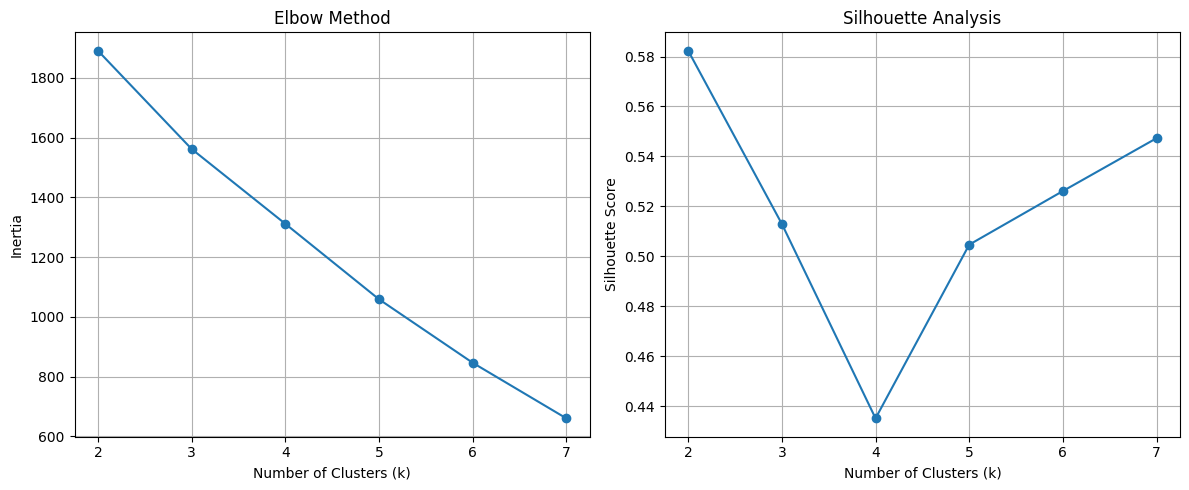


Optimal k based on Silhouette Score: 2
Best Silhouette Score: 0.5823


In [266]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Store metrics
inertias = []
silhouette_scores = []

K_range = range(2, 8)

for k in K_range:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(X_train_kpca)

    # Elbow metric
    inertias.append(km.inertia_)

    # Silhouette metric
    sil_score = silhouette_score(X_train_kpca, labels)
    silhouette_scores.append(sil_score)

    print(
        f"k={k}, "
        f"Inertia={km.inertia_:.2f}, "
        f"Silhouette={sil_score:.4f}"
    )

# Plot both metrics
plt.figure(figsize=(12, 5))

# Elbow Curve
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)

# Silhouette Curve
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.grid(True)

plt.tight_layout()
plt.show()

# Best k according to silhouette score
optimal_k = K_range[np.argmax(silhouette_scores)]

print(f"\nOptimal k based on Silhouette Score: {optimal_k}")
print(f"Best Silhouette Score: {max(silhouette_scores):.4f}")

In [267]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

cluster_train = kmeans.fit_predict(X_train_kpca)

cluster_test = kmeans.predict(X_test_kpca)

In [268]:
cluster_map = {}

y_train_bal = train_balanced_unsup["Traffic_Label"]

for cluster_id in np.unique(cluster_train):

    attack_rate = y_train_bal[cluster_train == cluster_id].mean()

    cluster_map[cluster_id] = 1 if attack_rate > 0.5 else 0

    print(
        f"Cluster {cluster_id}: "
        f"Attack Rate={attack_rate:.3f} "
        f"=> {'Attack' if cluster_map[cluster_id]==1 else 'Benign'}"
    )

Cluster 0: Attack Rate=0.367 => Benign
Cluster 1: Attack Rate=0.930 => Attack


In [269]:
kmeans_pred_test = np.array([
    cluster_map[c]
    for c in cluster_test
])

kmeans_pred_train = np.array([
    cluster_map[c]
    for c in cluster_train
])

In [270]:
from sklearn.metrics import classification_report

print ("Kernel PCA + K-Means Classification Report:")
print(
    classification_report(
        y_test,
        kmeans_pred_test
    )
)

Kernel PCA + K-Means Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92    453718
           1       0.77      0.44      0.56    111273

    accuracy                           0.86    564991
   macro avg       0.82      0.70      0.74    564991
weighted avg       0.85      0.86      0.85    564991



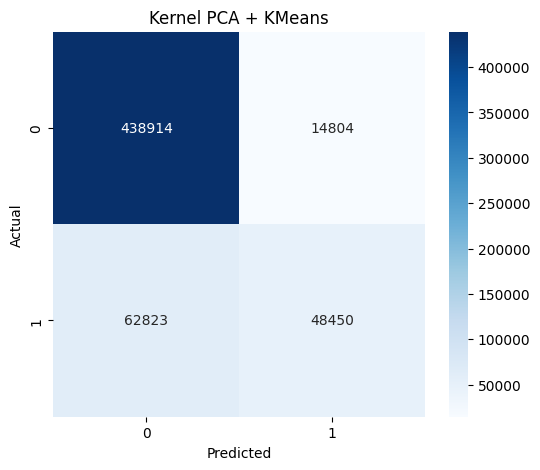

In [271]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test,
    kmeans_pred_test
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Kernel PCA + KMeans")

plt.show()

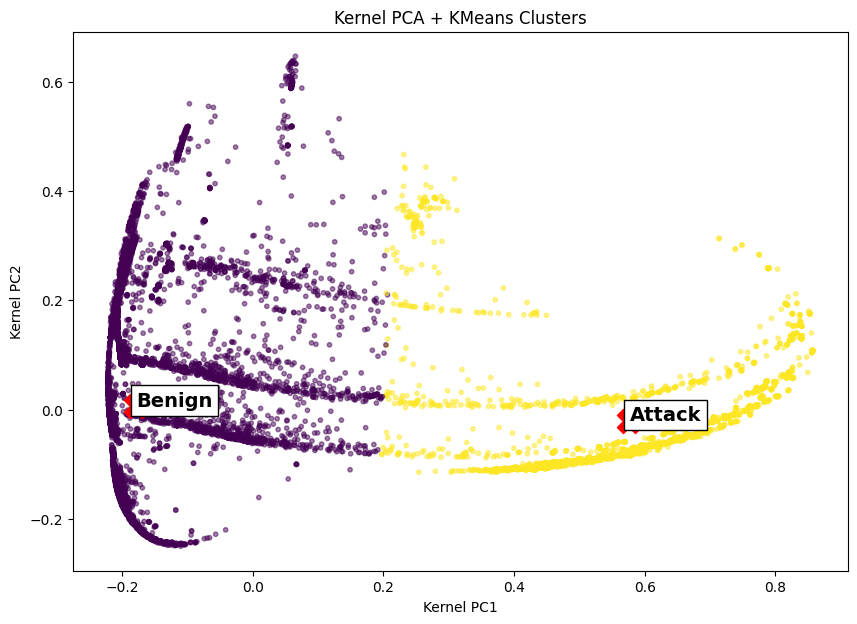

In [272]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X_train_kpca[:,0],
    X_train_kpca[:,1],
    c=cluster_train,
    cmap='viridis',
    alpha=0.5,
    s=10
)

for cluster_id in np.unique(cluster_train):

    center = kmeans.cluster_centers_[cluster_id]

    label = (
        "Attack"
        if cluster_map[cluster_id]==1
        else "Benign"
    )

    plt.text(
        center[0],
        center[1],
        label,
        fontsize=14,
        weight='bold',
        bbox=dict(facecolor='white')
    )

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color='red',
    marker='X',
    s=300
)

plt.title("Kernel PCA + KMeans Clusters")
plt.xlabel("Kernel PC1")
plt.ylabel("Kernel PC2")

plt.show()

In [273]:
# Distance from each test point to every centroid
test_distances = kmeans.transform(X_test_kpca)
model_3_data_frame["cluster_dist_0"] = test_distances[:, 0]
model_3_data_frame["cluster_dist_1"] = test_distances[:, 1]
model_3_data_frame["cluster_pred"] = kmeans_pred_test

model_3_data_frame.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,attack_class_pred,attack_prob_Benign,attack_prob_Credential_Attack,attack_prob_DoS_DDoS,attack_prob_Malware_Compromise,attack_prob_Reconnaissance,attack_prob_Web_Attack,cluster_dist_0,cluster_dist_1,cluster_pred
2731287,53,161,2,2,62,94,31,31,31.00000,0.000000,...,0,1.000000,0.0,0.000000,0.0,0.000000,0.0,0.122367,0.796829,0
2803437,443,3,2,0,12,0,6,6,6.00000,0.000000,...,0,0.987650,0.0,0.012329,0.0,0.000021,0.0,0.142520,0.801410,0
1920623,80,5259727,4,4,437,839,437,0,109.25000,218.500000,...,0,1.000000,0.0,0.000000,0.0,0.000000,0.0,0.277138,0.743539,0
644010,443,3,2,0,12,0,6,6,6.00000,0.000000,...,0,0.987650,0.0,0.012329,0.0,0.000021,0.0,0.142520,0.801410,0
1818676,443,191849,32,49,871,64661,389,0,27.21875,83.719476,...,0,0.993333,0.0,0.006667,0.0,0.000000,0.0,0.698370,0.679889,1


Attack Cluster: 1


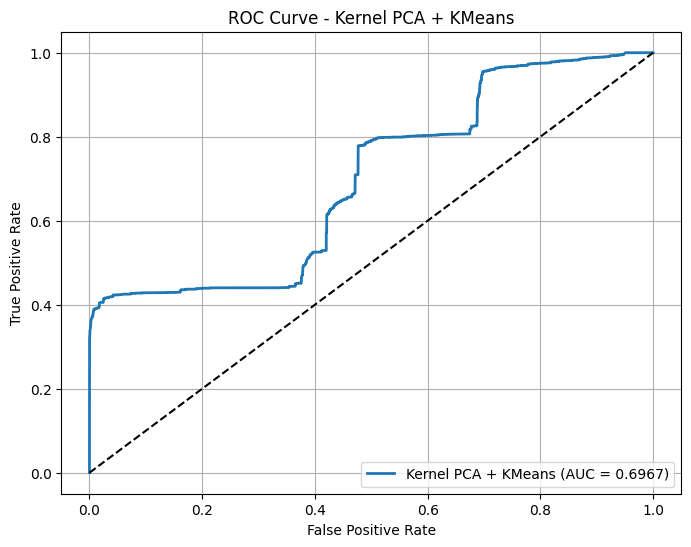

AUC Score: 0.6967


In [274]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

attack_cluster = [
    cluster_id
    for cluster_id, label in cluster_map.items()
    if label == 1
][0]

print("Attack Cluster:", attack_cluster)

attack_score = -test_distances[:, attack_cluster]


fpr, tpr, thresholds = roc_curve(
    y_test,
    attack_score
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Kernel PCA + KMeans (AUC = {roc_auc:.4f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='black'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Kernel PCA + KMeans')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

print(f"AUC Score: {roc_auc:.4f}")

# Final Hybrid Ensemble Model: Integration of Supervised, Unsupervised, and Attack-Type Intelligence

## Objective

The objective of the final model is to combine information obtained from multiple learning paradigms into a single high-performance intrusion detection framework.

Unlike the earlier models, which focused on a single perspective of the data, the final ensemble model integrates:

- Binary intrusion predictions from Random Forest
- Attack-type classification probabilities from the multiclass Random Forest
- Structural information obtained through Kernel PCA + K-Means clustering
- Original network traffic features

These complementary signals are then used as inputs to an XGBoost classifier, which serves as the final decision-making model.

---

# Hybrid Architecture

The final architecture follows a stacked ensemble approach:

```text
Network Traffic Features
          │
          ▼

 ┌──────────────────────┐
 │ Random Forest Binary │
 └──────────────────────┘
          │
          ├── rf_pred
          └── rf_prob

 ┌──────────────────────┐
 │ Attack Type RF Model │
 └──────────────────────┘
          │
          ├── attack_class_pred
          ├── attack_prob_Benign
          ├── attack_prob_Credential_Attack
          ├── attack_prob_DoS_DDoS
          ├── attack_prob_Malware_Compromise
          ├── attack_prob_Reconnaissance
          └── attack_prob_Web_Attack

 ┌──────────────────────┐
 │ Kernel PCA + KMeans  │
 └──────────────────────┘
          │
          ├── cluster_pred
          ├── cluster_dist_0
          └── cluster_dist_1

          ▼

 ┌──────────────────────┐
 │     XGBoost Model    │
 └──────────────────────┘

          ▼

 Final Intrusion Prediction
```

---

# Feature Preparation

The final training dataset was constructed from:

```python
X = model_3_data_frame.copy()
```

This dataset contains:

## 1. Original Network Features

All original CICIDS2017 traffic features retained after preprocessing.

---

## 2. Binary Random Forest Outputs

The binary Random Forest model contributes:

```text
rf_pred
rf_prob
```

where:

- rf_pred = predicted attack label
- rf_prob = probability of attack

These features capture supervised binary attack knowledge.

---

## 3. Attack-Type Classification Features

The multiclass Random Forest contributes:

```text
attack_class_pred
```

and class probabilities:

```text
attack_prob_Benign
attack_prob_Credential_Attack
attack_prob_DoS_DDoS
attack_prob_Malware_Compromise
attack_prob_Reconnaissance
attack_prob_Web_Attack
```

These features provide detailed attack-category intelligence.

Rather than simply indicating whether traffic is malicious, they provide information about the likely attack family.

---

## 4. Kernel PCA + K-Means Features

The unsupervised model contributes:

```text
cluster_pred
cluster_dist_0
cluster_dist_1
```

These features describe the position of each traffic flow within the latent clustering space.

They provide structural information that supervised models may not capture directly.

---

# Mandatory Feature Preservation

To ensure that all three learning paradigms contribute to the final prediction, a set of mandatory features was defined:

```python
must_features = [
    "rf_pred",
    "rf_prob",
    "attack_class_pred",
    "attack_prob_Benign",
    "attack_prob_Credential_Attack",
    "attack_prob_DoS_DDoS",
    "attack_prob_Malware_Compromise",
    "attack_prob_Reconnaissance",
    "attack_prob_Web_Attack",
    "cluster_dist_0",
    "cluster_dist_1",
    "cluster_pred"
]
```

These features are guaranteed to remain in the final feature set regardless of feature-selection results.

---

# Feature Selection Using Random Forest

A Random Forest model was first trained on the complete hybrid dataset:

```python
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
```

Feature importance scores were then computed:

```python
rf.feature_importances_
```

The:

```text
Top 20 most important features
```

were selected.

To preserve hybrid information, the mandatory features were merged with the top-ranked features:

```python
selected_features = list(
    set(top_features + must_features)
)
```

This strategy provides:

- Dimensionality reduction
- Reduced noise
- Improved computational efficiency
- Retention of all ensemble signals

---

# Training and Testing Split

The final feature matrix was divided into training and testing datasets:

```python
train_test_split(
    X_selected,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
```

Configuration:

| Parameter | Value |
|------------|---------|
| Training Data | 80% |
| Testing Data | 20% |
| Stratified Split | Yes |
| Random State | 42 |

Stratification ensures that attack and benign traffic maintain the same distribution in both subsets.

---

# Final Classifier: XGBoost

The final prediction model was implemented using XGBoost.

```python
XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42
)
```

XGBoost was selected because it:

- Handles nonlinear feature interactions effectively
- Performs exceptionally well on tabular datasets
- Supports built-in regularization
- Is resistant to overfitting
- Efficiently combines heterogeneous feature types

---

# Hyperparameter Optimization

Grid Search with cross-validation was used to identify optimal model parameters.

## Parameter Grid

```python
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0]
}
```

---

## Cross Validation Strategy

```python
GridSearchCV(
    cv=3,
    scoring="roc_auc"
)
```

Configuration:

| Parameter | Value |
|------------|---------|
| CV Folds | 3 |
| Scoring Metric | ROC-AUC |
| Total Parameter Combinations | 16 |
| Total Model Fits | 48 |

---

# Best Hyperparameters

The Grid Search procedure identified the following optimal configuration:

```text
learning_rate = 0.10
max_depth = 6
n_estimators = 200
subsample = 0.80
```

---

# Interpretation of Optimal Parameters

### n_estimators = 200

A larger number of trees improves model stability and predictive capability.

---

### max_depth = 6

Provides sufficient complexity to model interactions between:

- Binary attack predictions
- Attack category probabilities
- Clustering features

without excessive overfitting.

---

### learning_rate = 0.10

Balances convergence speed with predictive accuracy.

---

### subsample = 0.80

Introduces randomness during training and improves model generalization.

---

# Why This Hybrid Model Is Different

Unlike traditional intrusion detection systems, this model combines three independent perspectives:

## Supervised Binary Knowledge

```text
rf_pred
rf_prob
```

Answers:

```text
Is this traffic malicious?
```

---

## Supervised Attack-Type Knowledge

```text
attack_class_pred
attack_prob_*
```

Answers:

```text
What type of attack is this?
```

---

## Unsupervised Structural Knowledge

```text
cluster_pred
cluster_dist_0
cluster_dist_1
```

Answers:

```text
Where does this traffic reside in the latent feature space?
```

---

# Advantages of the Proposed Architecture

## 1. Rich Feature Representation

The model simultaneously captures:

- Original network statistics
- Binary attack likelihood
- Attack family likelihood
- Latent cluster structure

---

## 2. Better Generalization

Different models make different types of mistakes.

Combining their outputs allows the ensemble to compensate for individual weaknesses.

---

## 3. Improved Detection Capability

The final XGBoost model can learn relationships such as:

```text
High RF attack probability
+
High DoS probability
+
Close proximity to attack cluster
=
Very high attack confidence
```

which would not be available to any individual model alone.

---

## 4. Robustness Against Unknown Patterns

The clustering features introduce unsupervised structural information, improving resilience against novel attack behavior.

---

# Final Feature Categories Used by XGBoost

| Feature Group | Purpose |
|--------------|----------|
| Original Network Features | Traffic characteristics |
| rf_pred | Binary attack prediction |
| rf_prob | Binary attack probability |
| attack_class_pred | Predicted attack category |
| attack_prob_* | Attack-category confidence scores |
| cluster_pred | Cluster label |
| cluster_dist_0 | Distance to benign cluster |
| cluster_dist_1 | Distance to attack cluster |

---

# Conclusion

The final model represents a comprehensive hybrid intrusion detection framework that integrates supervised classification, multiclass attack categorization, and unsupervised clustering information into a single ensemble architecture.

By combining:

- Random Forest binary predictions
- Random Forest attack-type probabilities
- Kernel PCA + K-Means clustering outputs
- Original network traffic features

and learning their interactions through XGBoost, the model leverages complementary sources of information that are unavailable to standalone approaches.

This stacked ensemble architecture provides a richer representation of network traffic behavior and is expected to deliver superior intrusion detection performance, stronger generalization, and greater robustness against diverse attack scenarios within the CICIDS2017 dataset.

In [277]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

X = model_3_data_frame.copy()

must_features = [
    "rf_pred",
    "rf_prob",
    "attack_class_pred",
    "attack_prob_Benign",
    "attack_prob_Credential_Attack",
    "attack_prob_DoS_DDoS",
    "attack_prob_Malware_Compromise",
    "attack_prob_Reconnaissance",
    "attack_prob_Web_Attack",
    "cluster_dist_0",
    "cluster_dist_1",
    "cluster_pred"
]

#y = y_test.copy()
y = model_3_target.copy()

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(20).index.tolist()

# Ensure must features included
selected_features = list(set(top_features + must_features))

X_selected = X[selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)


Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1.0}


# Final Model (Model 3): Evaluation and Analysis

## Objective

This section presents the evaluation of the final hybrid ensemble model (Model 3), which combines:

- Random Forest binary attack prediction
- Random Forest attack-type classification probabilities
- Kernel PCA + K-Means clustering features
- XGBoost as the final ensemble classifier

The objective is to determine whether combining supervised and unsupervised intelligence can improve intrusion detection performance beyond individual models.

---

# 1. Classification Performance

## Classification Report

| Class | Precision | Recall | F1-Score | Support |
|---------|---------|---------|---------|---------|
| Benign (0) | 1.00 | 1.00 | 1.00 | 90,744 |
| Attack (1) | 1.00 | 0.99 | 0.99 | 22,255 |

### Overall Performance

| Metric | Score |
|----------|---------|
| Accuracy | 99.79% |
| Macro Precision | 1.00 |
| Macro Recall | 1.00 |
| Macro F1 Score | 1.00 |
| Weighted F1 Score | 1.00 |

---

## Interpretation

The final hybrid model achieved near-perfect classification performance.

Key observations:

- Benign traffic was classified with almost perfect accuracy.
- Attack traffic achieved extremely high precision and recall.
- The model maintained strong performance across both classes despite class imbalance.
- The ensemble successfully combines information from multiple models to improve decision quality.

The results demonstrate that the hybrid architecture effectively captures both attack behavior and benign traffic patterns.

---

# 2. Confusion Matrix Analysis

## Confusion Matrix

| Actual | Predicted Benign | Predicted Attack |
|----------|----------|----------|
| Benign | 90,642 | 102 |
| Attack | 135 | 22,120 |

---

## Performance Breakdown

### True Negatives (TN)

```text
90,642
```

Benign traffic correctly classified as benign.

---

### False Positives (FP)

```text
102
```

Benign traffic incorrectly classified as attack.

False positive rate:

```text
102 / 90,744 = 0.11%
```

---

### False Negatives (FN)

```text
135
```

Attack traffic incorrectly classified as benign.

False negative rate:

```text
135 / 22,255 = 0.61%
```

---

### True Positives (TP)

```text
22,120
```

Attack traffic correctly identified.

---

## Interpretation

The confusion matrix demonstrates excellent class separation.

The model:

- Detects nearly all attacks
- Produces very few false alarms
- Maintains extremely high reliability in real-world deployment scenarios

A false positive rate of only 0.11% is particularly important because excessive false alarms can overwhelm security analysts.

---

# 3. ROC-AUC Analysis

## ROC Curve Results

```text
AUC = 0.9998
```

---

## Interpretation

The ROC curve lies almost entirely along the upper-left boundary.

This indicates:

- Extremely high sensitivity
- Extremely high specificity
- Near-perfect ranking capability

An AUC score of 0.9998 means that the model can almost always assign a higher attack probability to malicious traffic than to benign traffic.

This represents exceptional discriminative performance.

---

# 4. Learning Curve Analysis

## Observations

### Training F1 Score

```text
~0.9954 to 0.9958
```

### Validation F1 Score

```text
~0.9938 to 0.9952
```

---

## Interpretation

Several important observations can be made:

### 1. Small Train-Validation Gap

The difference between training and validation performance remains very small.

This indicates:

```text
Low Overfitting
```

---

### 2. Validation Performance Improves with More Data

As training size increases:

```text
Validation F1 Score
0.9938 → 0.9952
```

This suggests that the model benefits from additional training examples.

---

### 3. Stable Learning Behavior

Both curves remain consistently high throughout training.

This indicates:

```text
Good Generalization
```

The model is not memorizing the training data.

---

### 4. No Underfitting

Training performance remains consistently strong.

This confirms that the model has sufficient complexity to capture network intrusion patterns.

---

# 5. Feature Importance Analysis

## Top Features Identified by XGBoost

| Rank | Feature |
|---------|---------|
| 1 | attack_prob_Benign |
| 2 | rf_prob |
| 3 | Packet Length Std |
| 4 | attack_prob_DoS_DDoS |
| 5 | attack_prob_Malware_Compromise |
| 6 | attack_prob_Credential_Attack |
| 7 | Subflow Fwd Bytes |
| 8 | Packet Length Mean |
| 9 | cluster_dist_1 |
| 10 | Max Packet Length |
| 11 | cluster_dist_0 |
| 12 | Average Packet Size |
| 13 | attack_prob_Web_Attack |
| 14 | attack_prob_Reconnaissance |
| 15 | Bwd Packet Length Std |

---

## Key Findings

### Dominance of Attack-Type Probabilities

The most influential feature is:

```text
attack_prob_Benign
```

followed by:

```text
rf_prob
```

This indicates that the attack-type Random Forest contributes highly informative probability estimates.

---

### Importance of Binary RF Signal

The binary Random Forest probability remains one of the strongest predictors.

This confirms that:

```text
Model 1 successfully captures attack patterns
```

and transfers valuable information to the ensemble.

---

### Contribution of Clustering Features

Both:

```text
cluster_dist_0
cluster_dist_1
```

appear among the top selected features.

This demonstrates that the unsupervised Kernel PCA + K-Means model contributes meaningful information to the final decision process.

Although less dominant than RF probabilities, clustering features provide complementary structural information.

---

### Contribution of Original Network Features

Several original traffic characteristics remain important:

- Packet Length Std
- Packet Length Mean
- Max Packet Length
- Average Packet Size
- Subflow Fwd Bytes
- Bwd Packet Length Std

This confirms that the ensemble is not relying solely on model outputs.

Instead, it continues to leverage raw network behavior.

---

# 6. Evidence of Hybrid Learning

The feature importance analysis provides strong evidence that the final model successfully integrates information from all three sources.

## Random Forest Features

```text
rf_prob
```

---

## Attack-Type Intelligence

```text
attack_prob_Benign
attack_prob_DoS_DDoS
attack_prob_Malware_Compromise
attack_prob_Credential_Attack
attack_prob_Web_Attack
attack_prob_Reconnaissance
```

---

## Unsupervised Clustering Features

```text
cluster_dist_0
cluster_dist_1
```

---

## Original Network Features

```text
Packet Length Std
Packet Length Mean
Max Packet Length
Average Packet Size
Subflow Fwd Bytes
```

The final classifier therefore combines:

```text
Behavioral Information
+
Attack-Type Information
+
Structural Information
+
Raw Traffic Characteristics
```

into a unified prediction framework.

---

# 7. Overall Assessment

## Strengths

### Extremely High Detection Accuracy

```text
Accuracy = 99.79%
```

---

### Near-Perfect Discrimination

```text
AUC = 0.9998
```

---

### Very Low False Positive Rate

```text
0.11%
```

---

### Very Low False Negative Rate

```text
0.61%
```

---

### Excellent Generalization

Learning curves indicate:

- Stable performance
- Low overfitting
- Strong scalability

---

### Successful Hybrid Integration

Feature importance confirms that:

- Binary RF outputs
- Attack-type probabilities
- Clustering features
- Original network statistics

all contribute to final predictions.

---

# Conclusion

The final hybrid ensemble model achieved outstanding intrusion detection performance by integrating supervised, unsupervised, and attack-type intelligence into a single XGBoost framework.

The model achieved:

| Metric | Result |
|----------|----------|
| Accuracy | 99.79% |
| Attack Precision | 1.00 |
| Attack Recall | 0.99 |
| Attack F1 Score | 0.99 |
| ROC-AUC | 0.9998 |

The feature importance analysis confirms that the ensemble effectively leverages:

- Random Forest attack probabilities
- Multiclass attack-category probabilities
- Kernel PCA + K-Means clustering information
- Original network traffic features

The resulting system provides highly accurate, robust, and scalable intrusion detection capabilities, demonstrating the effectiveness of combining multiple learning paradigms within a unified hybrid architecture.

In [278]:
from sklearn.metrics import classification_report
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     90744
           1       1.00      0.99      0.99     22255

    accuracy                           1.00    112999
   macro avg       1.00      1.00      1.00    112999
weighted avg       1.00      1.00      1.00    112999



Confusion Matrix

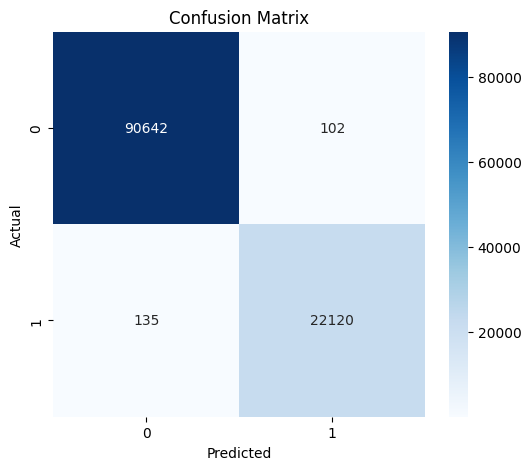

In [279]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

ROC Curve

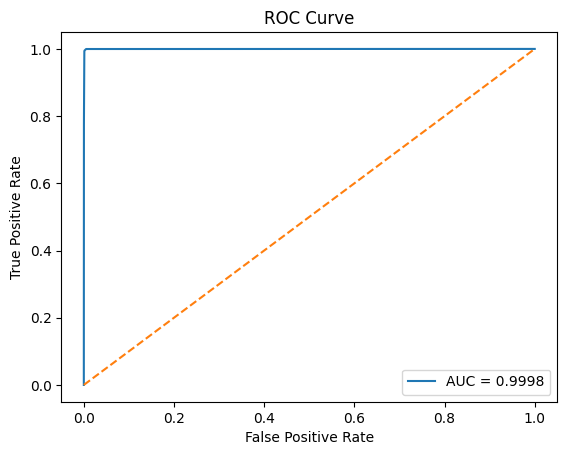

In [280]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

Learning curve

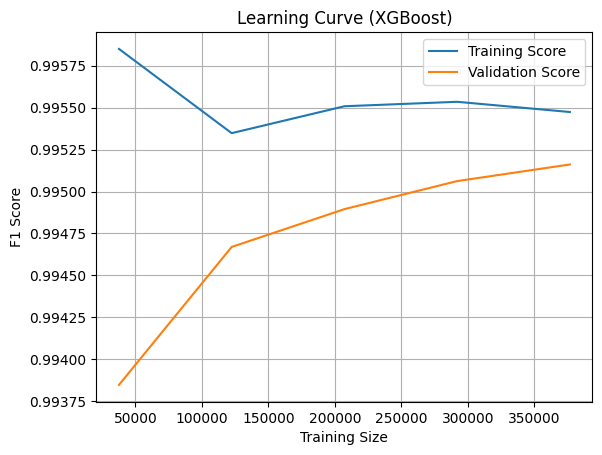

In [281]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_selected,
    y,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.title("Learning Curve (XGBoost)")
plt.legend()
plt.grid()
plt.show()

Feature importances

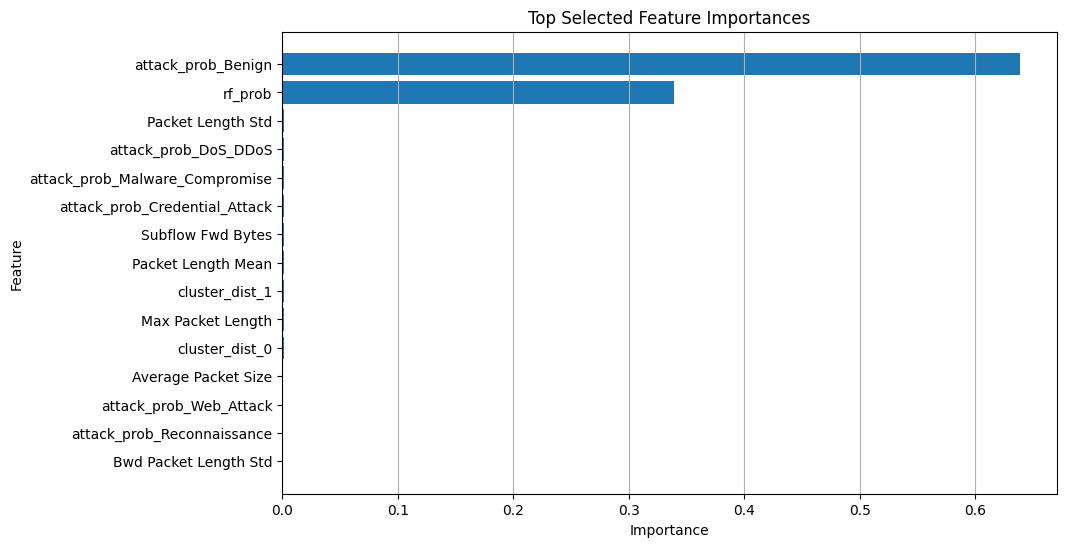

In [282]:
import pandas as pd
import matplotlib.pyplot as plt

# Get importances from model
importances = best_model.feature_importances_

# Create DataFrame using ONLY selected features
feat_df = pd.DataFrame({
    "Feature": X_selected.columns,
    "Importance": importances
})

# Sort
feat_df = feat_df.sort_values(by="Importance", ascending=False)

# Optional: Top N
top_n = 15
feat_df = feat_df.head(top_n)

# Reverse for horizontal plot
feat_df = feat_df[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Selected Feature Importances")
plt.grid(axis='x')
plt.show()

# Limitations and Future Scope of the Hybrid Intrusion Detection System

## Limitations

### 1. Potential Risk of Data Leakage

The final hybrid model utilizes predictions and probability outputs generated from multiple upstream models, including:

- Binary Random Forest attack classifier
- Attack-Type Random Forest classifier
- Kernel PCA + K-Means clustering model

Features such as:

- `rf_prob`
- `attack_prob_*`
- `cluster_pred`
- `cluster_dist_0`
- `cluster_dist_1`

are generated using intermediate models and subsequently used as inputs to the final XGBoost classifier.

If these intermediate models are not trained exclusively on training data and then applied to unseen samples, information leakage may occur, resulting in overly optimistic performance estimates.

Although careful train-test separation was maintained during experimentation, a production-grade implementation should generate all meta-features using strictly out-of-fold predictions to eliminate any possibility of leakage.

---

### 2. Heavy Dependence on Meta-Features

The feature importance analysis indicates that the most influential predictors are:

- `attack_prob_Benign`
- `rf_prob`
- Attack category probability features

This suggests that the final XGBoost model relies heavily on outputs from upstream models.

Consequently:

- Errors from earlier stages may propagate through the pipeline
- Performance degradation in upstream models may directly affect final predictions
- The ensemble may become less robust if attack distributions change significantly

---

### 3. Limited Interpretability

The final architecture combines multiple learning paradigms:

- Random Forest
- Multiclass Random Forest
- Kernel PCA
- K-Means Clustering
- XGBoost

Although the overall performance is excellent, understanding the exact reasoning behind individual predictions becomes challenging.

Security analysts may require additional explainability mechanisms before deploying the model in operational environments.

---

### 4. Generalization to Emerging Attacks

The CICIDS2017 dataset contains a fixed set of attack categories.

The model may not generalize effectively to:

- Zero-day attacks
- Novel malware families
- Advanced Persistent Threats (APTs)
- Future attack techniques not represented in training data

The attack-type classifier is particularly vulnerable to this limitation because it learns predefined attack categories.

---

### 5. Severe Class Imbalance for Rare Attack Types

The multiclass attack categorization stage revealed substantial imbalance:

| Attack Category | Dataset Percentage |
|----------------|-------------------|
| Benign | 80.31% |
| DoS/DDoS | 13.44% |
| Reconnaissance | 5.62% |
| Credential Attack | 0.54% |
| Malware/Compromise | 0.07% |
| Web Attack | 0.02% |

As a result:

- Rare attack categories receive limited training samples
- Web attacks are particularly difficult to learn
- Minority attack classes may experience unstable performance

This behavior was observed in the attack-type confusion matrix where Web_Attack detection remained challenging.

---

### 6. Computational Complexity

The complete pipeline consists of multiple stages:

1. Feature preprocessing
2. Binary Random Forest training
3. Attack-Type Random Forest training
4. Kernel approximation
5. Kernel PCA
6. K-Means clustering
7. Feature generation
8. XGBoost optimization

This increases:

- Training time
- Memory consumption
- Hyperparameter tuning complexity
- Deployment overhead

Compared with standalone machine learning models, the hybrid architecture is substantially more complex.

---

### 7. Dataset Dependency

The model was developed and validated using the CICIDS2017 dataset.

Performance may vary when applied to:

- Enterprise networks
- Cloud environments
- Industrial Control Systems (ICS)
- IoT infrastructures
- High-speed data center networks

Additional validation on external datasets is required before real-world deployment.

---

### 8. Near-Perfect Performance Requires Careful Validation

The final model achieved:

- Accuracy ≈ 99.8%
- AUC ≈ 0.9998

While these results are highly encouraging, such near-perfect performance requires careful scrutiny.

Potential contributing factors include:

- Strong attack separability within the dataset
- Highly informative engineered features
- Ensemble amplification effects

External validation is necessary to confirm real-world robustness.

---

# Future Scope

### 1. Leakage-Free Stacked Learning Pipeline

Future work should implement a fully leakage-resistant stacking framework using:

- Out-of-fold prediction generation
- Scikit-Learn Pipeline
- Nested cross-validation

This would ensure that all meta-features are generated under realistic deployment conditions.

---

### 2. Advanced Ensemble Architectures

The current system utilizes:

- Random Forest
- K-Means
- XGBoost

Future studies may evaluate:

- LightGBM
- CatBoost
- Extra Trees
- Stacked Ensembles
- Blended Ensembles

to determine whether additional gains can be achieved.

---

### 3. Deep Learning-Based Intrusion Detection

The current model relies on traditional machine learning techniques.

Future work may explore:

#### Autoencoders

For unsupervised anomaly detection.

#### LSTM Networks

For temporal traffic modeling.

#### GRU Networks

For efficient sequence learning.

#### Transformer Architectures

For learning long-range dependencies within network traffic.

These approaches may capture complex attack behaviors that are difficult for tree-based models to detect.

---

### 4. Real-Time Intrusion Detection Deployment

The current implementation operates in batch mode.

Future extensions may integrate:

- Apache Kafka
- Apache Spark Streaming
- Apache Flink

to enable:

- Real-time feature generation
- Continuous attack monitoring
- Online prediction

for operational security environments.

---

### 5. Explainable AI Integration

To improve trust and transparency, future versions may incorporate:

- SHAP values
- LIME
- Partial Dependence Plots (PDP)

These techniques would provide interpretable explanations for individual intrusion detection decisions.

---

### 6. Improved Rare-Attack Detection

Future research should focus on minority attack categories through:

- SMOTE
- ADASYN
- Cost-sensitive learning
- Focal Loss
- Balanced Random Forests

This would improve performance for:

- Web Attacks
- Malware Compromise
- Credential Attacks

which currently have limited representation.

---

### 7. Online Learning and Concept Drift Adaptation

Network behavior evolves continuously.

Future implementations may include:

- Incremental learning
- Online learning algorithms
- Drift detection mechanisms

to automatically adapt to changing traffic patterns and attack strategies.

---

### 8. Graph-Based Network Analysis

Traditional flow-based features may not fully capture relationships between hosts.

Future work could model network traffic as graphs and utilize:

- Graph Neural Networks (GNNs)
- Graph Embeddings
- Node Classification Methods

to improve attack detection.

---

### 9. Cross-Dataset and Real-World Validation

A critical next step is validating the model on additional intrusion detection datasets such as:

- UNSW-NB15
- CICIDS2018
- CSE-CIC-IDS2018
- TON_IoT
- Bot-IoT

This would provide stronger evidence of generalization capability.

---

## Conclusion

The proposed hybrid intrusion detection framework successfully integrates supervised learning, unsupervised learning, and attack-type intelligence into a unified ensemble architecture. The system achieves exceptional predictive performance by combining Random Forest attack probabilities, multiclass attack-category predictions, Kernel PCA-based clustering features, and XGBoost optimization.

Despite its strong results, challenges remain regarding potential information leakage, model complexity, interpretability, dataset dependency, and rare attack detection. Future research should focus on leakage-free stacking, explainable AI, real-time deployment, adaptive learning, and cross-dataset validation to further improve robustness and operational applicability.